# PROJE: MAKİNE ÖĞRENMESİ TABANLI ORMAN YANGINI RİSK TAHMİN SİSTEMİ

Amacımız: Montesinho Milli Parkı orman yangınları veri setini istatistiksel ve görsel olarak incelemek; literatür incelememizdeki temel makalelerin savunduğu teorileri kendi gözlerimizle kanıtlamak ve modelleme öncesi verinin teml yapısını analiz etmektir


## 1.Veri setine ilk bakış:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from IPython.display import display, HTML

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [3]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/raw/forestfires.csv')

print(f"Veri Seti Boyutu: {df.shape[0]} Satır, {df.shape[1]} Sütun\n")
print(f"Toplam Eksik Veri (NaN) Sayısı: {df.isnull().sum().sum()}\n")

display(df.head(10))
display(df.describe().T)

Veri Seti Boyutu: 517 Satır, 13 Sütun

Toplam Eksik Veri (NaN) Sayısı: 0



,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0,0.0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,3.1,0.0,0.0
7,8,6,aug,mon,91.5,145.4,608.2,10.7,8.0,86,2.2,0.0,0.0
8,8,6,sep,tue,91.0,129.5,692.6,7.0,13.1,63,5.4,0.0,0.0
9,7,5,sep,sat,92.5,88.0,698.6,7.1,22.8,40,4.0,0.0,0.0


,count,mean,std,min,25%,50%,75%,max
X,517.0,4.669246,2.313778,1.0,3.0,4.00,7.00,9.00
Y,517.0,4.299807,1.229900,2.0,4.0,4.00,5.00,9.00
FFMC,517.0,90.644681,5.520111,18.7,90.2,91.60,92.90,96.20
DMC,517.0,110.872340,64.046482,1.1,68.6,108.30,142.40,291.30
DC,517.0,547.940039,248.066192,7.9,437.7,664.20,713.90,860.60
ISI,517.0,9.021663,4.559477,0.0,6.5,8.40,10.80,56.10
temp,517.0,18.889168,5.806625,2.2,15.5,19.30,22.80,33.30
RH,517.0,44.288201,16.317469,15.0,33.0,42.00,53.00,100.00
wind,517.0,4.017602,1.791653,0.4,2.7,4.00,4.90,9.40
rain,517.0,0.021663,0.295959,0.0,0.0,0.00,0.00,6.40


In [4]:
list = []

for col in df.columns:
    col_type = str(df[col].dtype)
    nunique = df[col].nunique()
    mode_val = df[col].mode()[0]
    
    mean_val = np.nan
    median_val = np.nan
    min_val = np.nan
    max_val = np.nan
    
    if pd.api.types.is_numeric_dtype(df[col]):
        mean_val = round(df[col].mean(), 2)
        median_val = round(df[col].median(), 2)
        min_val = df[col].min()
        max_val = df[col].max()
        
    # Hesaplanan değerleri sözlük olarak listeye ekle
    list.append({
        "Değişken": col,
        "Veri Tipi": col_type,
        "Eşsiz Değer": nunique,
        "Mod (En Çok)": mode_val,
        "Ortalama": mean_val,
        "Medyan": median_val,
        "Min": min_val,
        "Max": max_val
    })

profil_df = pd.DataFrame(list)
profil_df.fillna('-', inplace=True)
display(profil_df.T)

,0,1,2,3,4,5,6,7,8,9,10,11,12
Değişken,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
Veri Tipi,int64,int64,object,object,float64,float64,float64,float64,float64,int64,float64,float64,float64
Eşsiz Değer,9,7,12,7,106,215,219,119,192,75,21,7,251
Mod (En Çok),4,4,aug,sun,91.6,99.0,745.3,9.6,17.4,27,2.2,0.0,0.0
Ortalama,4.67,4.3,-,-,90.64,110.87,547.94,9.02,18.89,44.29,4.02,0.02,12.85
Medyan,4.0,4.0,-,-,91.6,108.3,664.2,8.4,19.3,42.0,4.0,0.0,0.52
Min,1.0,2.0,-,-,18.7,1.1,7.9,0.0,2.2,15.0,0.4,0.0,0.0
Max,9.0,9.0,-,-,96.2,291.3,860.6,56.1,33.3,100.0,9.4,6.4,1090.84


In [65]:
kopya_sayisi = df.duplicated().sum()
print(f'Tekrar eden (kopya) satır sayısı: {kopya_sayisi}')

print('Nem (RH) 0 ile 100 arasında mı?      :', df['RH'].between(0, 100).all())
print('Sıcaklık -15 ile 50°C arasında mı?    :', df['temp'].between(-15, 50).all())
print(
    'Rüzgar ve Yağmur negatif değil mi?    :',
    (df['wind'] >= 0).all() and (df['rain'] >= 0).all(),
)
print(
    'FWI endeksleri 0 dan büyük mü?       :',
    (df[['FFMC', 'DMC', 'DC', 'ISI']] >= 0).all().all(),
)

Tekrar eden (kopya) satır sayısı: 4
Nem (RH) 0 ile 100 arasında mı?      : True
Sıcaklık -15 ile 50°C arasında mı?    : True
Rüzgar ve Yağmur negatif değil mi?    : True
FWI endeksleri 0 dan büyük mü?       : True


Yanan Alan Gini Katsayısı: 0.88


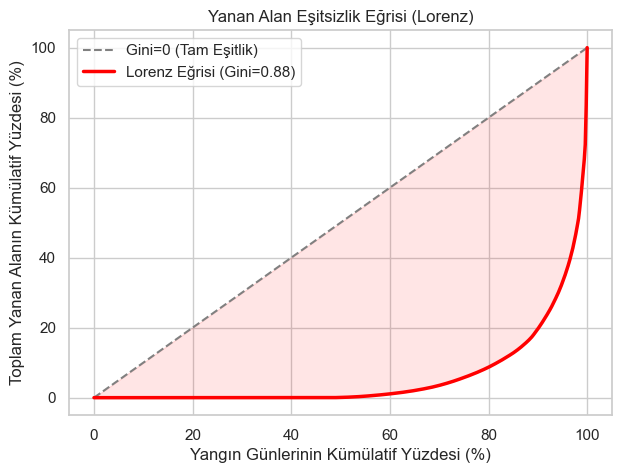

In [66]:
def gini_hesapla(dizi):
    dizi = np.sort(dizi)
    n = len(dizi)
    indeks = np.arange(1, n + 1)
    return (np.sum((2 * indeks - n - 1) * dizi)) / (n * np.sum(dizi))


gini_degeri = gini_hesapla(df['area'].values)
print(f'Yanan Alan Gini Katsayısı: {gini_degeri:.2f}')

alan_sirali = np.sort(df['area'].values)
x_yuzde = np.linspace(0, 100, len(alan_sirali))
y_yuzde = np.cumsum(alan_sirali) / np.sum(alan_sirali) * 100

plt.figure(figsize=(7, 5))
plt.plot(
    [0, 100],
    [0, 100],
    '--',
    color='gray',
    label='Gini=0 (Tam Eşitlik)',
)
plt.plot(
    x_yuzde,
    y_yuzde,
    color='red',
    lw=2.5,
    label=f'Lorenz Eğrisi (Gini={gini_degeri:.2f})',
)
plt.fill_between(x_yuzde, y_yuzde, x_yuzde, color='red', alpha=0.1)

plt.title('Yanan Alan Eşitsizlik Eğrisi (Lorenz)')
plt.xlabel('Yangın Günlerinin Kümülatif Yüzdesi (%)')
plt.ylabel('Toplam Yanan Alanın Kümülatif Yüzdesi (%)')
plt.legend(loc='upper left')
plt.show()

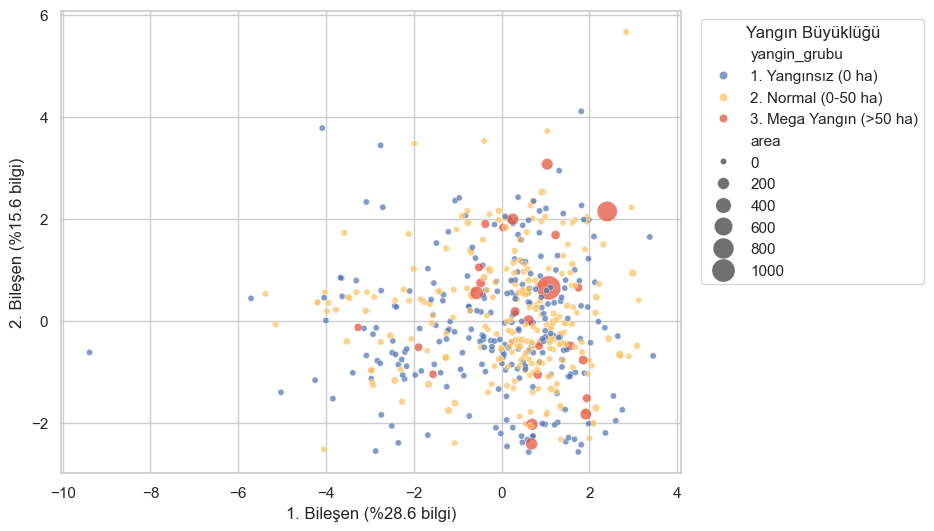

In [68]:
sayisal_kolonlar = [
    'X',
    'Y',
    'FFMC',
    'DMC',
    'DC',
    'ISI',
    'temp',
    'RH',
    'wind',
    'rain',
]
x_olcekli = StandardScaler().fit_transform(df[sayisal_kolonlar])

pca = PCA(n_components=2)
coords = pca.fit_transform(x_olcekli)
df['PC1'] = coords[:, 0]
df['PC2'] = coords[:, 1]

df['yangin_grubu'] = '1. Yangınsız (0 ha)'
df.loc[(df['area'] > 0) & (df['area'] <= 50), 'yangin_grubu'] = '2. Normal (0-50 ha)'
df.loc[df['area'] > 50, 'yangin_grubu'] = '3. Mega Yangın (>50 ha)'

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='yangin_grubu',
    palette=['#4C72B0', '#FBC15E', '#E24A33'],
    size='area',
    sizes=(20, 300),
    alpha=0.7,
)

plt.xlabel(f'1. Bileşen (%{pca.explained_variance_ratio_[0]*100:.1f} bilgi)')
plt.ylabel(f'2. Bileşen (%{pca.explained_variance_ratio_[1]*100:.1f} bilgi)')
plt.legend(title='Yangın Büyüklüğü', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

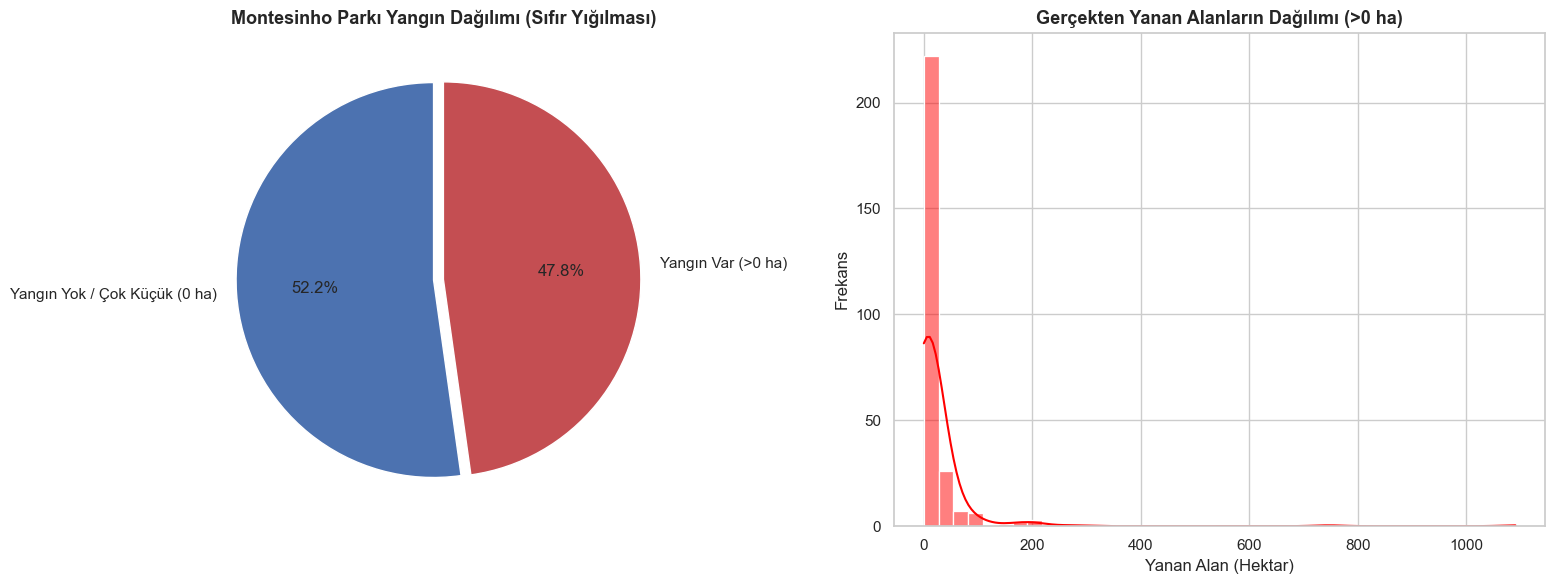

In [15]:
df['fire_occurred'] = df['area'].apply(lambda x: 1 if x > 0 else 0)
fire_counts = df['fire_occurred'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].pie(fire_counts, labels=['Yangın Yok / Çok Küçük (0 ha)', 'Yangın Var (>0 ha)'], 
            autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'], startangle=90, explode=(0.05, 0))
axes[0].set_title('Montesinho Parkı Yangın Dağılımı (Sıfır Yığılması)', fontweight='bold', fontsize=13)

sns.histplot(df[df['area'] > 0]['area'], bins=40, kde=True, color='red', ax=axes[1])
axes[1].set_title('Gerçekten Yanan Alanların Dağılımı (>0 ha)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Yanan Alan (Hektar)')
axes[1].set_ylabel('Frekans')

plt.tight_layout()
plt.show()

1. Pasta Grafiği:
Veri setimizdeki kayıtların %52.2'sinde yanan alan 0.0 hektardır (yangın çıkmamış veya büyümeden sönmüş). Geriye kalan %47.8'lik kısımda ise yangın vakası mevcuttur. Bu durum, hedef değişkenin normal bir dağılım göstermediğini ve tek bir noktada (sıfırda) aşırı yığıldığını net bir şekilde kanıtlar.

1. Histogram :
Sıfırları dışarıda bırakıp sadece yangın çıkan (alan > 0) kayıtlara baktığımızda bile, verinin ezici bir çoğunluğunun 0 ile 50 hektar aralığına sıkıştığını; ancak grafiğin sağa doğru (1000 hektara kadar) uzanan devasa ve ince bir kuyruğa sahip olduğunu görüyoruz.

1. DÜŞÜK RİSK  : 0.00 ha - 30.32 ha arası
2. ORTA RİSK   : 30.32 ha - 105.66 ha arası
3. YÜKSEK RİSK : 105.66 ha - 278.53 ha arası
4. KRİTİK RİSK : 278.53 ha ve üzeri



,Risk Rozeti,Alan Aralığı (Hektar),Vaka Sayısı
0,1. DÜŞÜK RİSK,0.00 - 30.32,229
1,2. ORTA RİSK,30.32 - 105.66,32
2,3. YÜKSEK RİSK,105.66 - 278.53,7
3,4. KRİTİK RİSK,278.53 ve üzeri,2


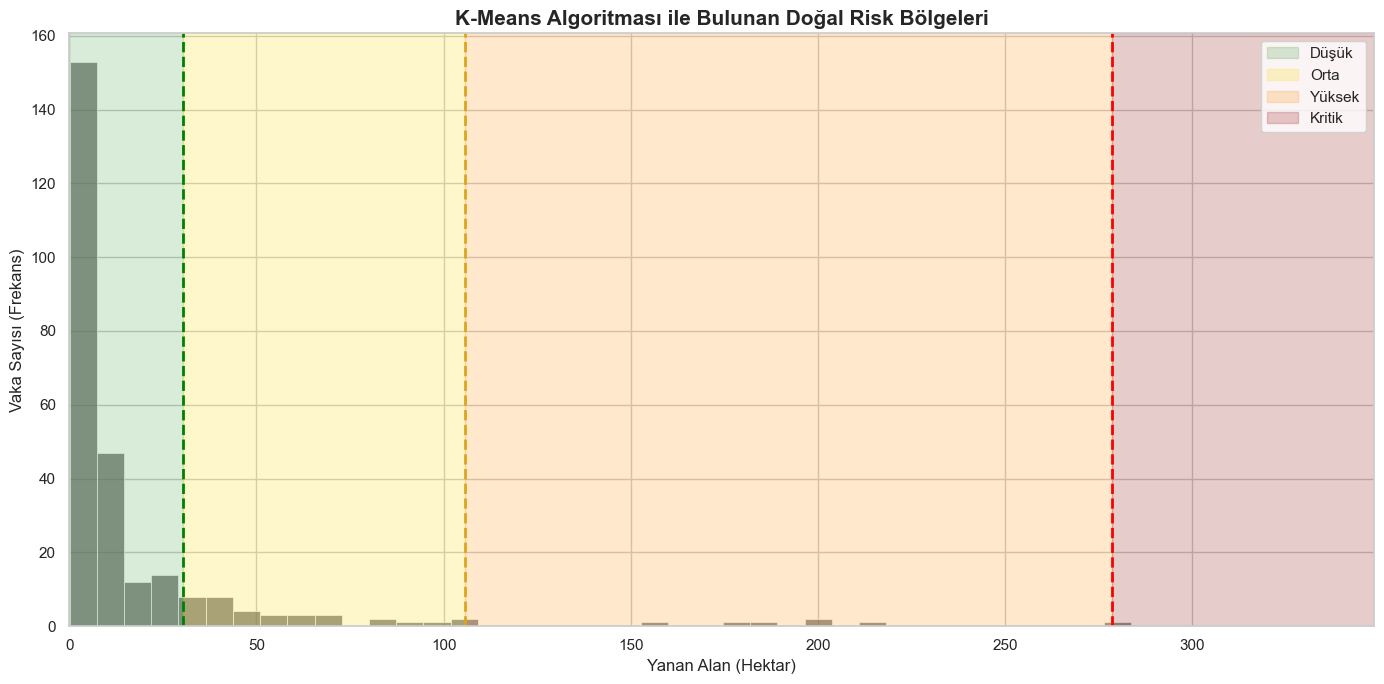

Risk sınırları K-Means algoritması ile belirlenmiş olup, yeşil bölge düşük risk, sarı bölge orta risk, turuncu bölge yüksek risk ve kırmızı bölge kritik risk olarak sınıflandırılmıştır.

Tablodan ve yeşil bölgeden de net bir şekilde anlaşıldığı üzere, yangınların çok büyük bir kısmı
(229 adet vaka) 30.32 hektarın altında sönmektedir.


In [28]:
df_fires = df[df['area'] > 0].copy()
X = df_fires['area'].values.reshape(-1, 1)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_fires['Risk_Cluster'] = kmeans.fit_predict(X)

sinirlar = sorted(df_fires.groupby('Risk_Cluster')['area'].max().values)

s1, s2, s3 = sinirlar[0], sinirlar[1], sinirlar[2]

print(f"1. DÜŞÜK RİSK  : 0.00 ha - {s1:.2f} ha arası")
print(f"2. ORTA RİSK   : {s1:.2f} ha - {s2:.2f} ha arası")
print(f"3. YÜKSEK RİSK : {s2:.2f} ha - {s3:.2f} ha arası")
print(f"4. KRİTİK RİSK : {s3:.2f} ha ve üzeri\n")

risk_tablosu = pd.DataFrame([
    {"Risk Rozeti": " 1. DÜŞÜK RİSK", "Alan Aralığı (Hektar)": f"0.00 - {s1:.2f}", "Vaka Sayısı": len(df_fires[df_fires['area'] <= s1])},
    {"Risk Rozeti": " 2. ORTA RİSK", "Alan Aralığı (Hektar)": f"{s1:.2f} - {s2:.2f}", "Vaka Sayısı": len(df_fires[(df_fires['area'] > s1) & (df_fires['area'] <= s2)])},
    {"Risk Rozeti": " 3. YÜKSEK RİSK", "Alan Aralığı (Hektar)": f"{s2:.2f} - {s3:.2f}", "Vaka Sayısı": len(df_fires[(df_fires['area'] > s2) & (df_fires['area'] <= s3)])},
    {"Risk Rozeti": " 4. KRİTİK RİSK", "Alan Aralığı (Hektar)": f"{s3:.2f} ve üzeri", "Vaka Sayısı": len(df_fires[df_fires['area'] > s3])}
])
display(risk_tablosu)

# Görselleştirme 

plt.figure(figsize=(14, 7))
sns.histplot(df_fires['area'], bins=150, color='dimgray', alpha=0.7, kde=False)

plt.axvspan(0, s1, color='green', alpha=0.15, label='Düşük')
plt.axvspan(s1, s2, color='gold', alpha=0.20, label='Orta')
plt.axvspan(s2, s3, color='darkorange', alpha=0.20, label='Yüksek')
plt.axvspan(s3, s3 + 200, color='darkred', alpha=0.20, label='Kritik')

plt.axvline(s1, color='green', linestyle='--', linewidth=2)
plt.axvline(s2, color='goldenrod', linestyle='--', linewidth=2)
plt.axvline(s3, color='red', linestyle='--', linewidth=2)

plt.title('K-Means Algoritması ile Bulunan Doğal Risk Bölgeleri', fontsize=15, fontweight='bold')
plt.xlabel('Yanan Alan (Hektar)', fontsize=12)
plt.ylabel('Vaka Sayısı (Frekans)', fontsize=12)

plt.xlim(0, s3 + 70) 

plt.legend()
plt.tight_layout()
plt.show()

print(f"Risk sınırları K-Means algoritması ile belirlenmiş olup, yeşil bölge düşük risk, sarı bölge orta risk, turuncu bölge yüksek risk ve kırmızı bölge kritik risk olarak sınıflandırılmıştır.\n")
print(f"Tablodan ve yeşil bölgeden de net bir şekilde anlaşıldığı üzere, yangınların çok büyük bir kısmı")
print(f"({risk_tablosu.iloc[0]['Vaka Sayısı']} adet vaka) {s1:.2f} hektarın altında sönmektedir.")


,Mekansal Boyut,ANOVA F,ANOVA p-değeri,Kruskal H,Kruskal p-değeri
0,X Koordinatı (Batı - Doğu),0.7235,0.6708,14.8555,0.0620
1,Y Koordinatı (Kuzey - Güney),1.7103,0.1165,9.1047,0.1678


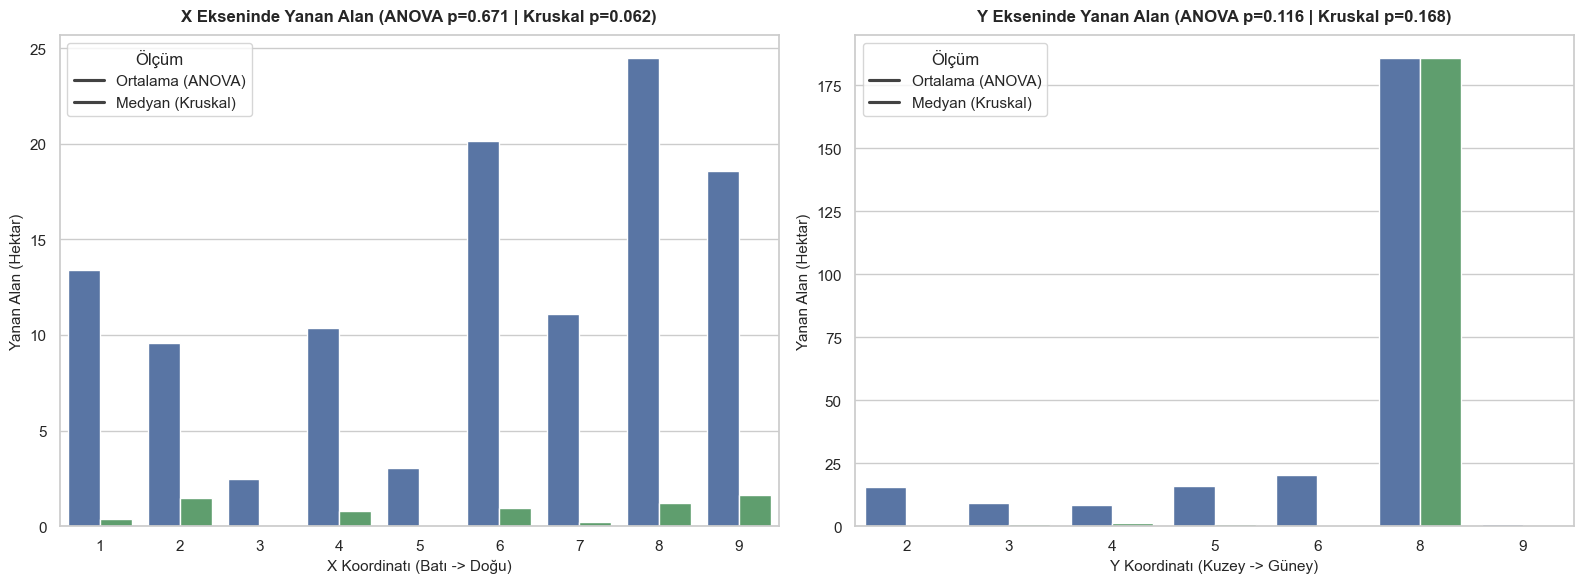

In [30]:
x_gruplari = [grup['area'].values for _, grup in df.groupby('X')]
y_gruplari = [grup['area'].values for _, grup in df.groupby('Y')]
anova_x = stats.f_oneway(*x_gruplari)
kw_x = stats.kruskal(*x_gruplari)
anova_y = stats.f_oneway(*y_gruplari)
kw_y = stats.kruskal(*y_gruplari)
istatistik_ozeti = pd.DataFrame(
    {
        'Mekansal Boyut': [
            'X Koordinatı (Batı - Doğu)',
            'Y Koordinatı (Kuzey - Güney)',
        ],
        'ANOVA F': [anova_x.statistic, anova_y.statistic],
        'ANOVA p-değeri': [anova_x.pvalue, anova_y.pvalue],
        'Kruskal H': [kw_x.statistic, kw_y.statistic],
        'Kruskal p-değeri': [kw_x.pvalue, kw_y.pvalue],
    }
).round(4)
display(istatistik_ozeti)
# 4. Görselleştirme: 
x_ozet = df.groupby('X')['area'].agg(['mean', 'median']).reset_index()
y_ozet = df.groupby('Y')['area'].agg(['mean', 'median']).reset_index()
sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=x_ozet.melt(id_vars='X', value_vars=['mean', 'median']),
    x='X',
    y='value',
    hue='variable',
    palette=['#4C72B0', '#55A868'],
    ax=axes[0],
)
axes[0].set_title(
    f'X Ekseninde Yanan Alan (ANOVA p={anova_x.pvalue:.3f} | Kruskal p={kw_x.pvalue:.3f})',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[0].set_xlabel('X Koordinatı (Batı -> Doğu)', fontsize=11)
axes[0].set_ylabel('Yanan Alan (Hektar)', fontsize=11)
axes[0].legend(title='Ölçüm', labels=['Ortalama (ANOVA)', 'Medyan (Kruskal)'])
sns.barplot(
    data=y_ozet.melt(id_vars='Y', value_vars=['mean', 'median']),
    x='Y',
    y='value',
    hue='variable',
    palette=['#4C72B0', '#55A868'],
    ax=axes[1],
)
axes[1].set_title(
    f'Y Ekseninde Yanan Alan (ANOVA p={anova_y.pvalue:.3f} | Kruskal p={kw_y.pvalue:.3f})',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[1].set_xlabel('Y Koordinatı (Kuzey -> Güney)', fontsize=11)
axes[1].set_ylabel('Yanan Alan (Hektar)', fontsize=11)
axes[1].legend(title='Ölçüm', labels=['Ortalama (ANOVA)', 'Medyan (Kruskal)'])
plt.tight_layout()
plt.show()

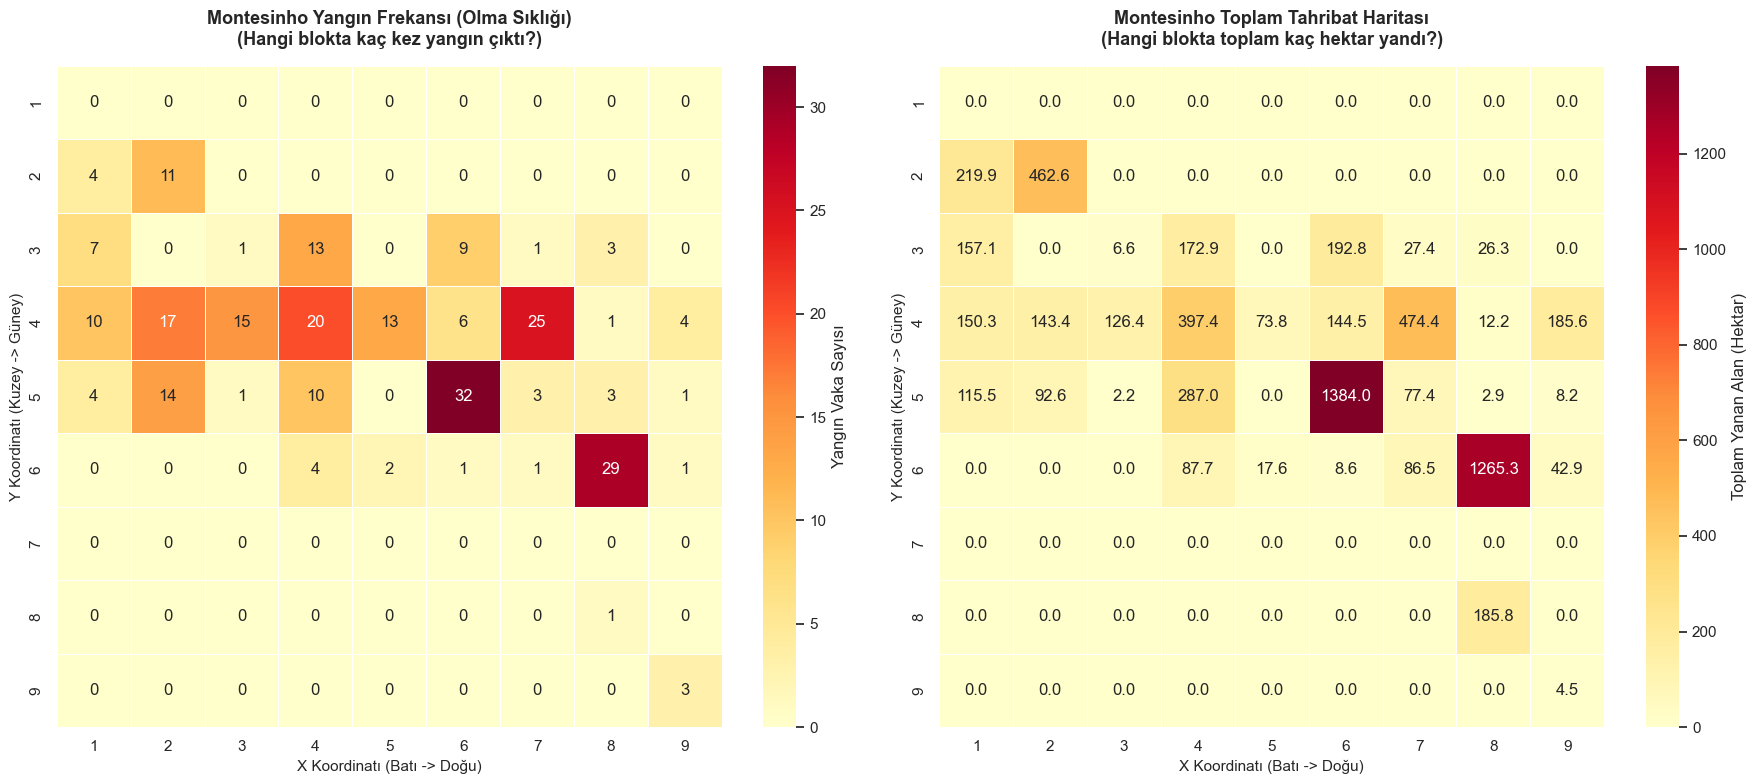

--- EN TEHLİKELİ TOP 3 BLOK ---
Blok (X=6, Y=5) -> Toplam 32.0 yangında 1384.05 hektar yandı
Blok (X=8, Y=6) -> Toplam 29.0 yangında 1265.30 hektar yandı
Blok (X=7, Y=4) -> Toplam 25.0 yangında 474.37 hektar yandı


In [31]:
yangin_df = df[df['area'] > 0].copy()
frekans_matrisi = (
    yangin_df.pivot_table(index='Y', columns='X', values='area', aggfunc='count')
    .reindex(index=range(1, 10), columns=range(1, 10))
    .fillna(0)
)
alan_matrisi = (
    yangin_df.pivot_table(index='Y', columns='X', values='area', aggfunc='sum')
    .reindex(index=range(1, 10), columns=range(1, 10))
    .fillna(0)
)
sns.set_theme(style='white')
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(
    frekans_matrisi,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Yangın Vaka Sayısı'},
    ax=axes[0],
)
axes[0].set_title(
    'Montesinho Yangın Frekansı (Olma Sıklığı)\n(Hangi blokta kaç kez yangın çıktı?)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
axes[0].set_xlabel('X Koordinatı (Batı -> Doğu)', fontsize=11)
axes[0].set_ylabel('Y Koordinatı (Kuzey -> Güney)', fontsize=11)
sns.heatmap(
    alan_matrisi,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Toplam Yanan Alan (Hektar)'},
    ax=axes[1],
)
axes[1].set_title(
    'Montesinho Toplam Tahribat Haritası\n(Hangi blokta toplam kaç hektar yandı?)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('X Koordinatı (Batı -> Doğu)', fontsize=11)
axes[1].set_ylabel('Y Koordinatı (Kuzey -> Güney)', fontsize=11)
plt.tight_layout()
plt.show()
en_cok_yananlar = (
    yangin_df.groupby(['X', 'Y'])['area']
    .agg(['count', 'sum'])
    .reset_index()
    .sort_values(by='sum', ascending=False)
    .head(3)
)
print('--- EN TEHLİKELİ TOP 3 BLOK ---')
for idx, row in en_cok_yananlar.iterrows():
    print(
        f"Blok (X={int(row['X'])}, Y={int(row['Y'])}) -> Toplam {row['count']} yangında {row['sum']:.2f} hektar yandı"
    )

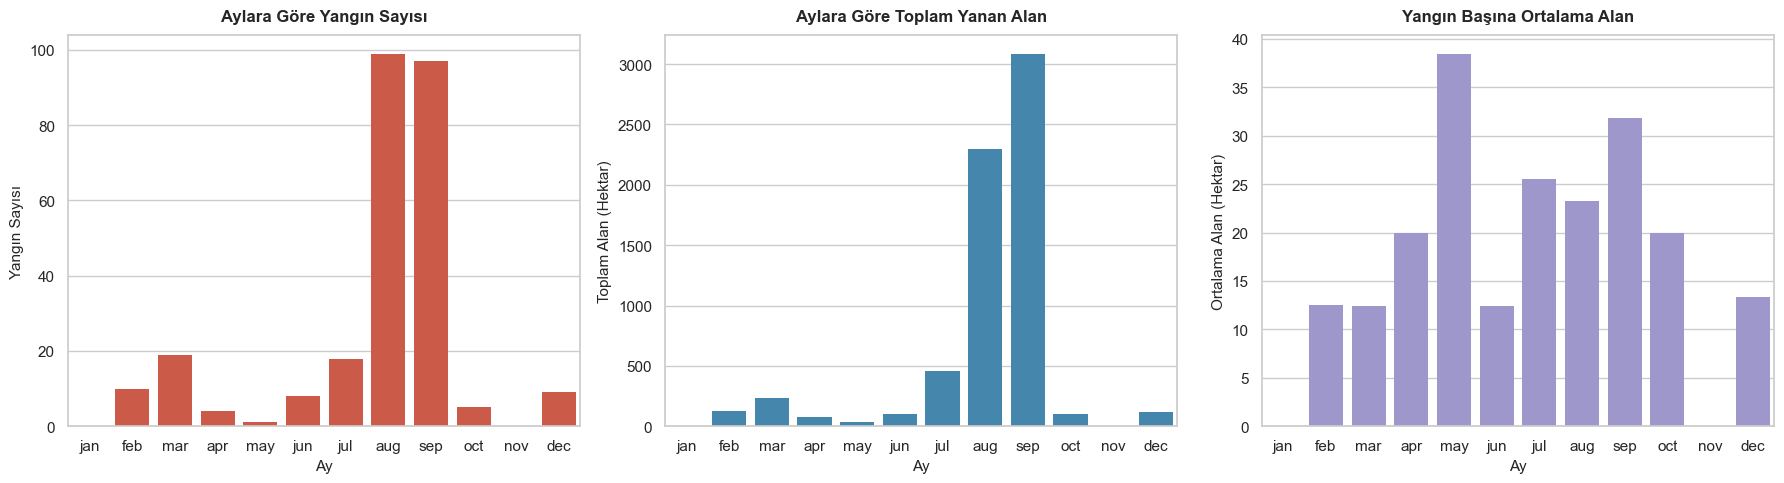

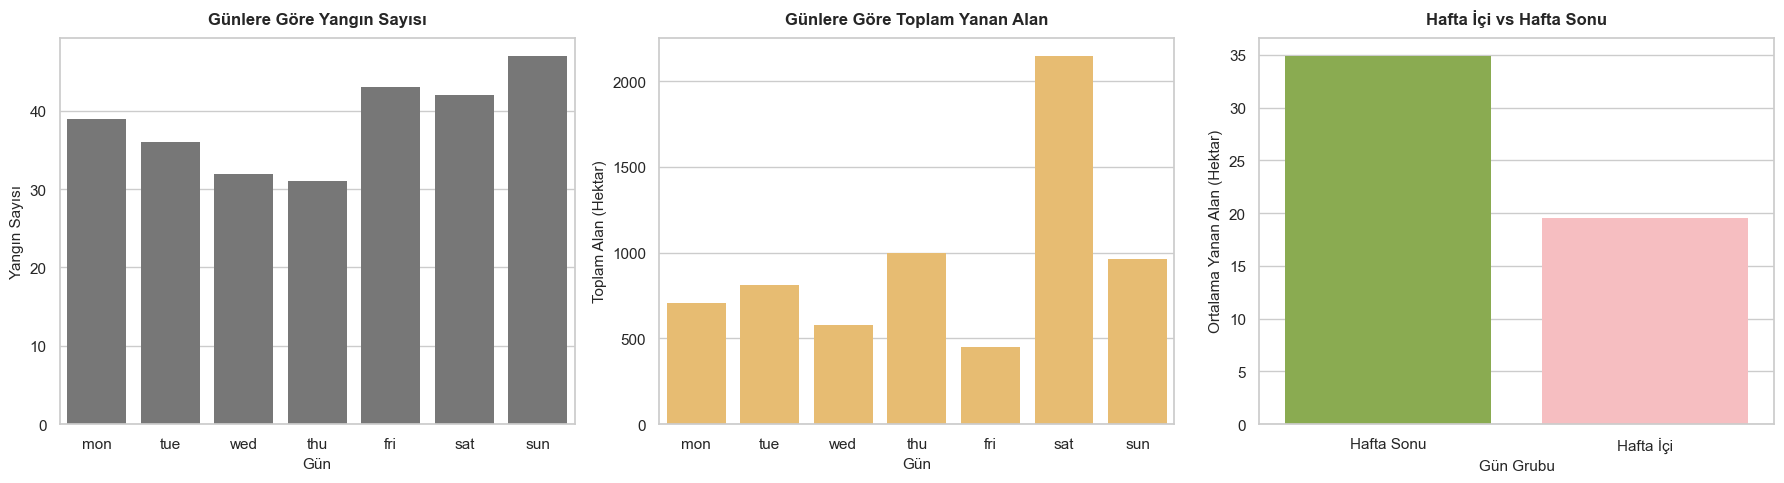

--- HAFTA İÇİ vs HAFTA SONU YANGIN ÖZETİ ---


,is_weekend,count,sum,mean
0,Hafta Sonu,89,3104.79,34.89
1,Hafta İçi,181,3537.26,19.54


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ay_sirasi = [
    'jan',
    'feb',
    'mar',
    'apr',
    'may',
    'jun',
    'jul',
    'aug',
    'sep',
    'oct',
    'nov',
    'dec',
]
gun_sirasi = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']

df['month'] = pd.Categorical(df['month'], categories=ay_sirasi, ordered=True)
df['day'] = pd.Categorical(df['day'], categories=gun_sirasi, ordered=True)

df['is_weekend'] = df['day'].isin(['sat', 'sun']).map({True: 'Hafta Sonu', False: 'Hafta İçi'})

yanginlar = df[df['area'] > 0].copy()

aylik_ozet = (
    yanginlar.groupby('month', observed=True)['area']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=aylik_ozet,
    x='month',
    y='count',
    color = '#E24A33',
    ax=axes[0],
    edgecolor='none',
)
axes[0].set_title(
    'Aylara Göre Yangın Sayısı',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[0].set_xlabel('Ay', fontsize=11)
axes[0].set_ylabel('Yangın Sayısı', fontsize=11)

sns.barplot(
    data=aylik_ozet,
    x='month',
    y='sum',
    color = '#348ABD',
    ax=axes[1],
    edgecolor='none',
)
axes[1].set_title(
    'Aylara Göre Toplam Yanan Alan',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[1].set_xlabel('Ay', fontsize=11)
axes[1].set_ylabel('Toplam Alan (Hektar)', fontsize=11)

sns.barplot(
    data=aylik_ozet,
    x='month',
    y='mean',
    color='#988ED5',
    ax=axes[2],
    edgecolor='none',
)
axes[2].set_title(
    'Yangın Başına Ortalama Alan',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[2].set_xlabel('Ay', fontsize=11)
axes[2].set_ylabel('Ortalama Alan (Hektar)', fontsize=11)

plt.tight_layout()
plt.show()

gunluk_ozet = (
    yanginlar.groupby('day', observed=True)['area']
    .agg(['count', 'sum'])
    .reset_index()
)
haftasonu_ozet = (
    yanginlar.groupby('is_weekend', observed=True)['area']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=gunluk_ozet,
    x='day',
    y='count',
    color='#777777',
    ax=axes[0],
    edgecolor='none',
)
axes[0].set_title(
    'Günlere Göre Yangın Sayısı',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[0].set_xlabel('Gün', fontsize=11)
axes[0].set_ylabel('Yangın Sayısı', fontsize=11)

sns.barplot(
    data=gunluk_ozet,
    x='day',
    y='sum',
    color='#FBC15E',
    ax=axes[1],
    edgecolor='none',
)
axes[1].set_title(
    'Günlere Göre Toplam Yanan Alan',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[1].set_xlabel('Gün', fontsize=11)
axes[1].set_ylabel('Toplam Alan (Hektar)', fontsize=11)

sns.barplot(
    data=haftasonu_ozet,
    x='is_weekend',
    y='mean',
    palette=['#8EBA42', '#FFB5B8'],
    ax=axes[2],
    edgecolor='none',
)
axes[2].set_title(
    'Hafta İçi vs Hafta Sonu',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[2].set_xlabel('Gün Grubu', fontsize=11)
axes[2].set_ylabel('Ortalama Yanan Alan (Hektar)', fontsize=11)

plt.tight_layout()
plt.show()

print('--- HAFTA İÇİ vs HAFTA SONU YANGIN ÖZETİ ---')
display(haftasonu_ozet.round(2))

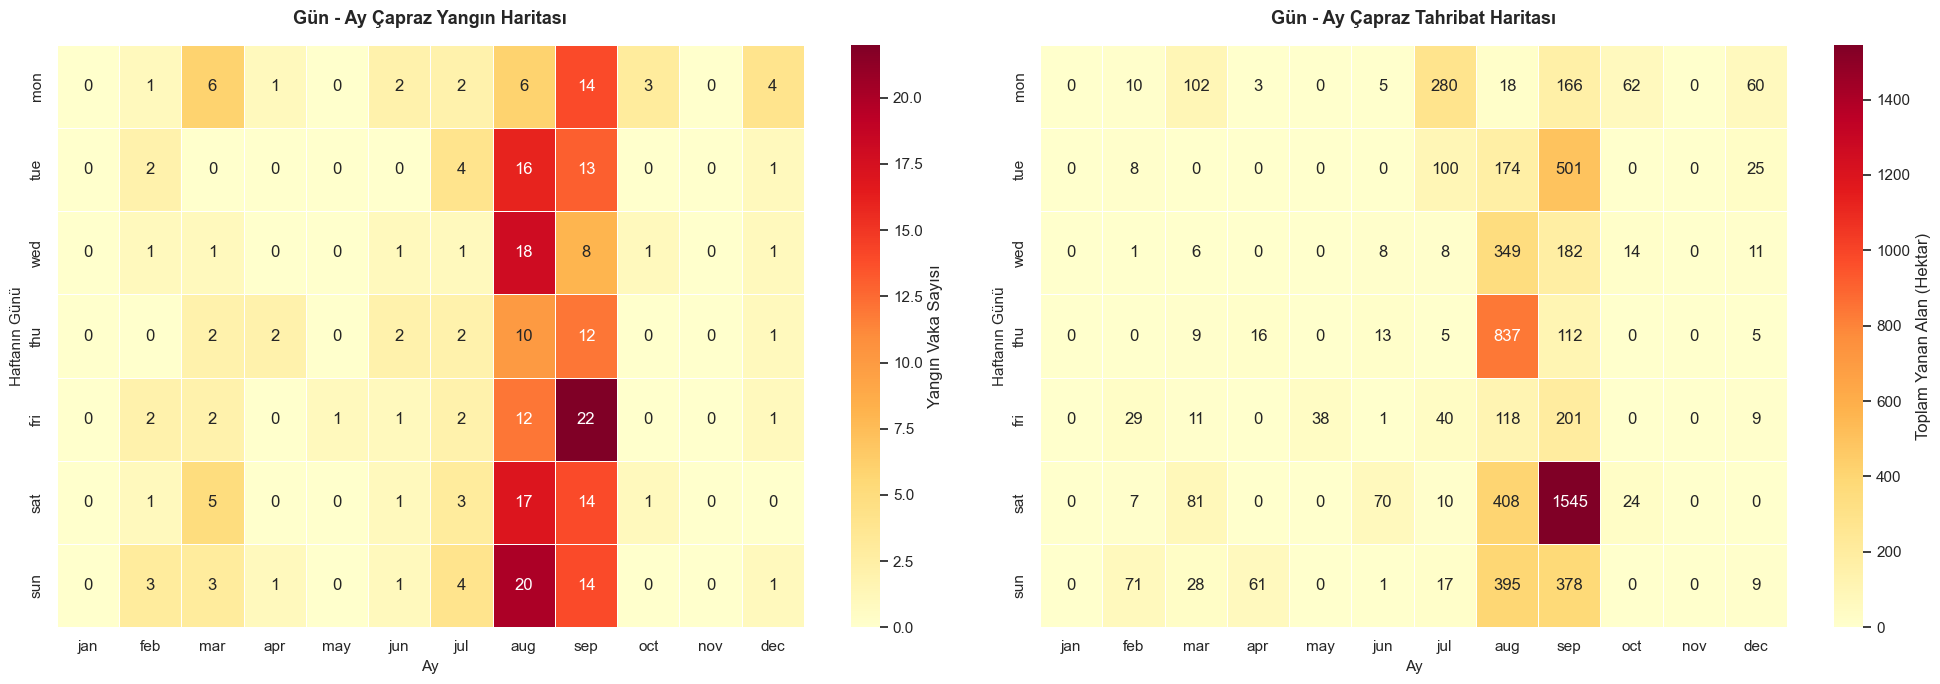

Zaman: [SEP ayının SAT günü] -> 14 yangında toplam 1545.11 ha yanmış, (Ortalama: 110.37 ha/yangın)
Zaman: [AUG ayının THU günü] -> 10 yangında toplam 837.17 ha yanmış, (Ortalama: 83.72 ha/yangın)
Zaman: [SEP ayının TUE günü] -> 13 yangında toplam 500.69 ha yanmış, (Ortalama: 38.51 ha/yangın)


In [36]:
ay_sirasi = [
    'jan',
    'feb',
    'mar',
    'apr',
    'may',
    'jun',
    'jul',
    'aug',
    'sep',
    'oct',
    'nov',
    'dec',
]
gun_sirasi = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']

df['month'] = pd.Categorical(df['month'], categories=ay_sirasi, ordered=True)
df['day'] = pd.Categorical(df['day'], categories=gun_sirasi, ordered=True)

yanginlar = df[df['area'] > 0].copy()

frekans_matrisi = (
    yanginlar.pivot_table(index='day', columns='month', values='area', aggfunc='count')
    .reindex(index=gun_sirasi, columns=ay_sirasi)
    .fillna(0)
)

alan_matrisi = (
    yanginlar.pivot_table(index='day', columns='month', values='area', aggfunc='sum')
    .reindex(index=gun_sirasi, columns=ay_sirasi)
    .fillna(0)
)

sns.set_theme(style='white')
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(
    frekans_matrisi,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Yangın Vaka Sayısı'},
    ax=axes[0],
)
axes[0].set_title(
    'Gün - Ay Çapraz Yangın Haritası',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
axes[0].set_xlabel('Ay', fontsize=11)
axes[0].set_ylabel('Haftanın Günü', fontsize=11)
sns.heatmap(
    alan_matrisi,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Toplam Yanan Alan (Hektar)'},
    ax=axes[1],
)
axes[1].set_title(
    'Gün - Ay Çapraz Tahribat Haritası',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('Ay', fontsize=11)
axes[1].set_ylabel('Haftanın Günü', fontsize=11)

plt.tight_layout()
plt.show()
en_tehlikeli_zamanlar = (
    yanginlar.groupby(['month', 'day'], observed=True)['area']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
    .sort_values(by='sum', ascending=False)
    .head(3)
)

for idx, row in en_tehlikeli_zamanlar.iterrows():
    print(
        f"Zaman: [{row['month'].upper()} ayının {row['day'].upper()} günü] -> {row['count']} yangında toplam {row['sum']:.2f} ha yanmış, (Ortalama: {row['mean']:.2f} ha/yangın)"
    )

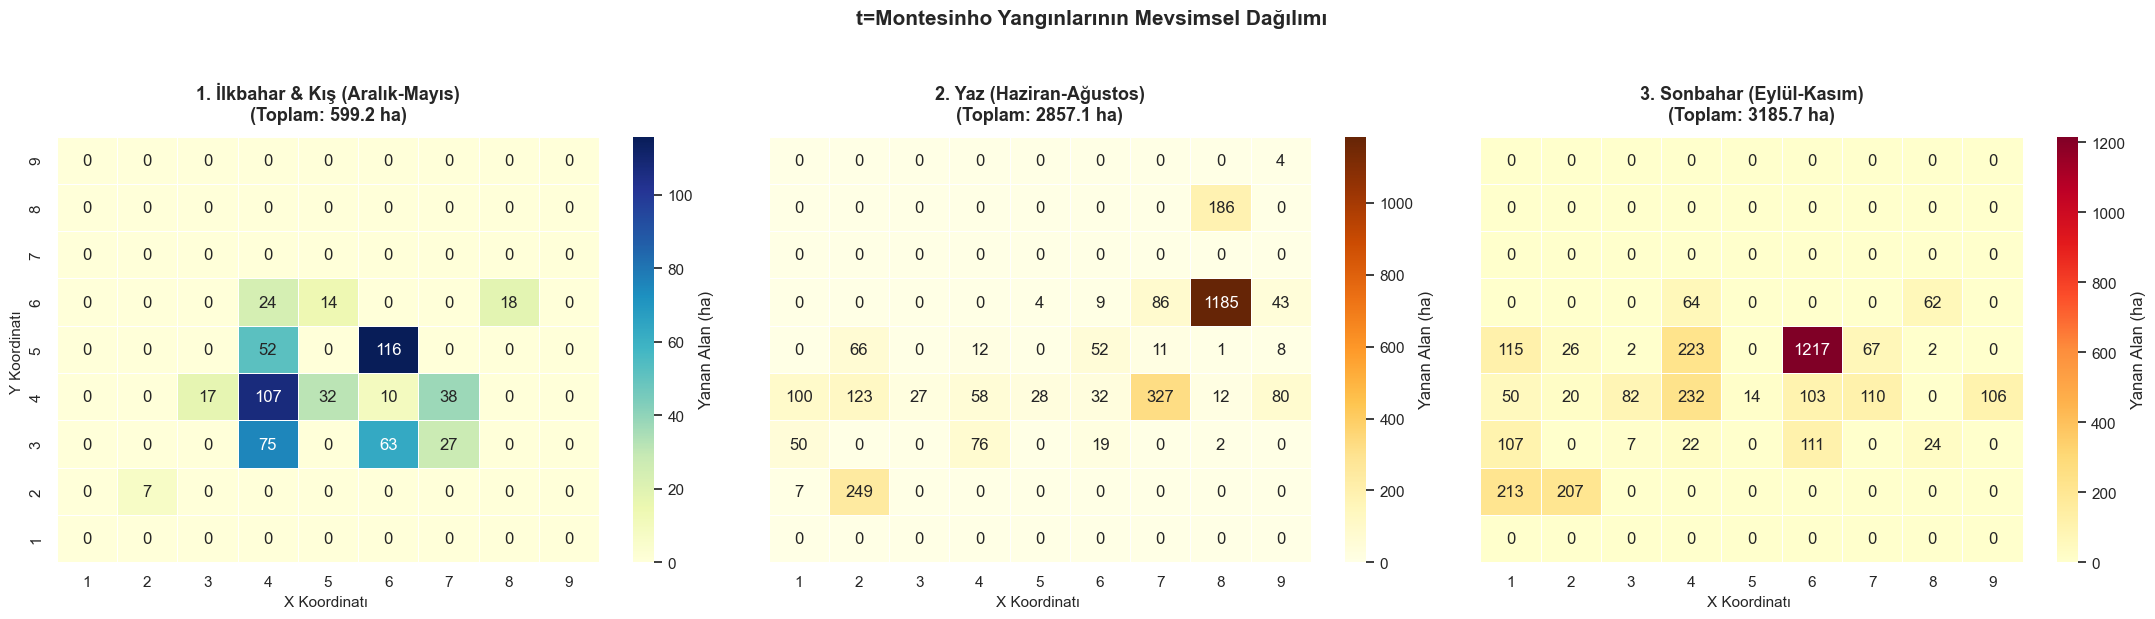

--- MEVSİMLERE GÖRE YANGININ  ---
[1. İlkbahar & Kış (Aralık-Mayıs)] -> En Tehlikeli Blok: [X=6, Y=5] -> Toplam 115.78 hektar yanmış
[2. Yaz (Haziran-Ağustos)] -> En Tehlikeli Blok: [X=8, Y=6] -> Toplam 1184.87 hektar yanmış
[3. Sonbahar (Eylül-Kasım)] -> En Tehlikeli Blok: [X=6, Y=5] -> Toplam 1216.51 hektar yanmış


In [57]:
mevsim_sozlugu = {
    'dec': '1. İlkbahar & Kış (Aralık-Mayıs)',
    'jan': '1. İlkbahar & Kış (Aralık-Mayıs)',
    'feb': '1. İlkbahar & Kış (Aralık-Mayıs)',
    'mar': '1. İlkbahar & Kış (Aralık-Mayıs)',
    'apr': '1. İlkbahar & Kış (Aralık-Mayıs)',
    'may': '1. İlkbahar & Kış (Aralık-Mayıs)',
    'jun': '2. Yaz (Haziran-Ağustos)',
    'jul': '2. Yaz (Haziran-Ağustos)',
    'aug': '2. Yaz (Haziran-Ağustos)',
    'sep': '3. Sonbahar (Eylül-Kasım)',
    'oct': '3. Sonbahar (Eylül-Kasım)',
    'nov': '3. Sonbahar (Eylül-Kasım)',
}
df['deneysel_mevsim'] = df['month'].map(mevsim_sozlugu)
yanginlar = df[df['area'] > 0].copy()

sns.set_theme(style='white')
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharex=True, sharey=True)
mevsimler = sorted(df['deneysel_mevsim'].unique())
renk_paletleri = [
    'YlGnBu',
    'YlOrBr',
    'YlOrRd',
]  

for i, mevsim in enumerate(mevsimler):
    mevsim_verisi = yanginlar[yanginlar['deneysel_mevsim'] == mevsim]
    izgara_matrisi = (
        mevsim_verisi.pivot_table(index='Y', columns='X', values='area', aggfunc='sum')
        .reindex(index=range(1, 10), columns=range(1, 10))
        .fillna(0)
    )
    
    sns.heatmap(
        izgara_matrisi.iloc[::-1],
        annot=True,
        fmt='.0f',
        cmap=renk_paletleri[i],
        linewidths=0.5,
        cbar_kws={'label': 'Yanan Alan (ha)'},
        ax=axes[i],
    )
    axes[i].set_title(
        f'{mevsim}\n(Toplam: {mevsim_verisi["area"].sum():.1f} ha)',
        fontsize=13,
        fontweight='bold',
        pad=12,
    )
    axes[i].set_xlabel('X Koordinatı ', fontsize=11)
    if i == 0:
        axes[i].set_ylabel('Y Koordinatı ', fontsize=11)
    else:
        axes[i].set_ylabel('')
plt.suptitle( "t=Montesinho Yangınlarının Mevsimsel Dağılımı",
    fontsize=15,
    fontweight='bold',
    y=1.03,
)
plt.tight_layout()
plt.show()
print('--- MEVSİMLERE GÖRE YANGININ  ---')
for mevsim in mevsimler:
    mevsim_verisi = yanginlar[yanginlar['deneysel_mevsim'] == mevsim]
    zirve_blok = (
        mevsim_verisi.groupby(['X', 'Y'], observed=True)['area']
        .sum()
        .reset_index()
        .sort_values(by='area', ascending=False)
        .iloc[0]
    )
    print(
        f"[{mevsim}] -> En Tehlikeli Blok: [X={int(zirve_blok['X'])}, Y={int(zirve_blok['Y'])}] -> Toplam {zirve_blok['area']:.2f} hektar yanmış"
    )

DENEYSEL MAKALE ANALİZİ 2: 7 GÜNLÜK TAM YELPAZEDE İNSAN FAKTÖRÜ İSPATI (ADIM 6.2)


,day_ordered,toplam_gun,ort_sicaklik,medyan_sicaklik,ort_nem,medyan_nem,toplam_yanan_alan,ort_yanan_alan
0,Pazartesi,74,16.95,17.55,44.66,42.0,706.53,9.55
1,Salı,64,19.44,19.40,43.67,41.0,807.79,12.62
2,Çarşamba,54,20.43,20.45,40.11,36.0,578.60,10.71
3,Perşembe,61,19.70,20.40,38.80,38.0,997.10,16.35
4,Cuma,85,17.95,18.70,46.66,43.0,447.24,5.26
5,Cumartesi,84,19.35,19.10,43.40,41.5,2144.86,25.53
6,Pazar,95,19.07,19.80,48.97,44.0,959.93,10.10


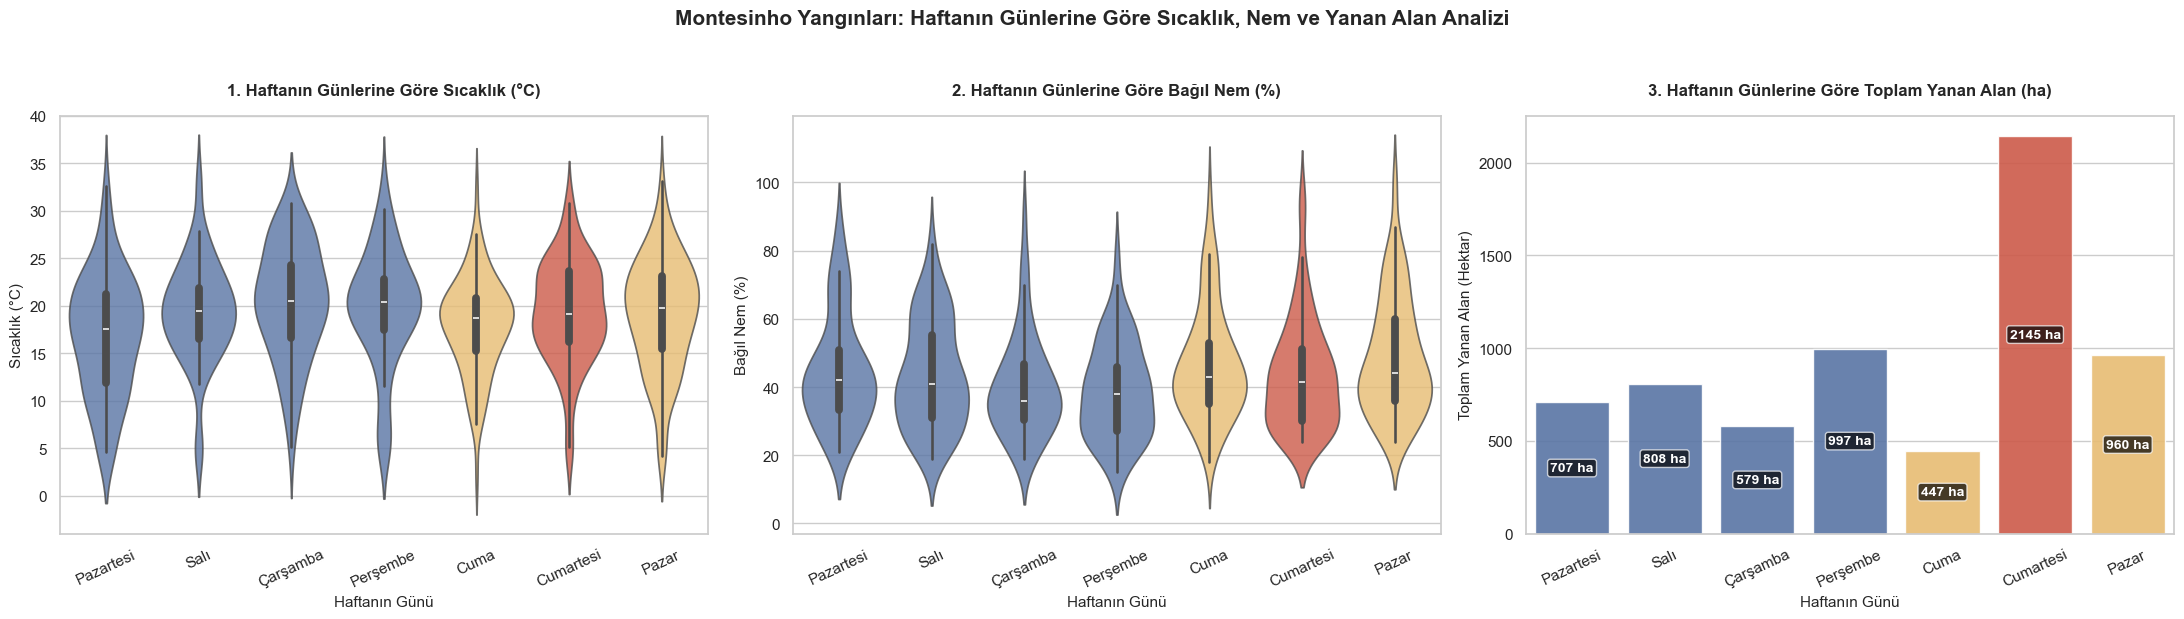

 Hafta İçi Ort. Sıcaklık   : 18.99°C | Ortalama Nem: %42.03
 Hafta Sonu + Cuma Ort. Sıcaklık: 18.80°C | Ortalama Nem: %46.45
  Hafta İçi 4 Günün TOPLAM Yanan Alanı    : 3090.02 hektar (Günlük ort: 772.50 ha)
 Hafta Sonu 3 Günün TOPLAM Yanan Alanı   : 3552.03 hektar (Günlük ort: 1184.01 ha)!


In [61]:
gun_sirasi = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']
gun_isimleri_tr = [
    'Pazartesi',
    'Salı',
    'Çarşamba',
    'Perşembe',
    'Cuma',
    'Cumartesi',
    'Pazar',
]

df['day_ordered'] = pd.Categorical(df['day'], categories=gun_sirasi, ordered=True)

gunluk_analiz = (
    df.groupby('day_ordered', observed=True)
    .agg(
        toplam_gun=('day', 'count'),
        ort_sicaklik=('temp', 'mean'),
        medyan_sicaklik=('temp', 'median'),
        ort_nem=('RH', 'mean'),
        medyan_nem=('RH', 'median'),
        toplam_yanan_alan=('area', 'sum'),
        ort_yanan_alan=('area', 'mean'),
    )
    .reset_index()
)

gunluk_analiz['day_ordered'] = gun_isimleri_tr

print('=' * 85)
print(
    'DENEYSEL MAKALE ANALİZİ 2: 7 GÜNLÜK TAM YELPAZEDE İNSAN FAKTÖRÜ İSPATI (ADIM 6.2)'
)
print('=' * 85)
display(gunluk_analiz.round(2))

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

palet_7gun = [
    '#4C72B0',
    '#4C72B0',
    '#4C72B0',
    '#4C72B0',
    '#FBC15E',
    '#E24A33',
    '#FBC15E',
]

sns.violinplot(
    data=df,
    x='day_ordered',
    y='temp',
    palette=palet_7gun,
    ax=axes[0],
    inner='boxplot',
    alpha=0.8,
)
axes[0].set_title(
    '1. Haftanın Günlerine Göre Sıcaklık (°C)',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[0].set_xlabel('Haftanın Günü', fontsize=11)
axes[0].set_ylabel('Sıcaklık (°C)', fontsize=11)
axes[0].set_xticklabels(gun_isimleri_tr, rotation=25)

sns.violinplot(
    data=df,
    x='day_ordered',
    y='RH',
    palette=palet_7gun,
    ax=axes[1],
    inner='boxplot',
    alpha=0.8,
)
axes[1].set_title(
    '2. Haftanın Günlerine Göre Bağıl Nem (%)',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('Haftanın Günü', fontsize=11)
axes[1].set_ylabel('Bağıl Nem (%)', fontsize=11)
axes[1].set_xticklabels(gun_isimleri_tr, rotation=25)

sns.barplot(
    data=gunluk_analiz,
    x='day_ordered',
    y='toplam_yanan_alan',
    palette=palet_7gun,
    ax=axes[2],
    alpha=0.9,
)
axes[2].set_title(
    '3. Haftanın Günlerine Göre Toplam Yanan Alan (ha)',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[2].set_xlabel('Haftanın Günü', fontsize=11)
axes[2].set_ylabel('Toplam Yanan Alan (Hektar)', fontsize=11)
axes[2].set_xticklabels(gun_isimleri_tr, rotation=25)

for p in axes[2].patches:
    height = p.get_height()
    if height > 0:
        axes[2].annotate(
            f'{height:.0f} ha',
            (p.get_x() + p.get_width() / 2.0, height / 2),
            ha='center',
            va='center',
            fontsize=10,
            color='white',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7),
        )

plt.suptitle(
    'Montesinho Yangınları: Haftanın Günlerine Göre Sıcaklık, Nem ve Yanan Alan Analizi',
    fontsize=15,
    fontweight='bold',
    y=1.03,
)
plt.tight_layout()
plt.show()

hafta_ici = df[df['day'].isin(['mon', 'tue', 'wed', 'thu'])]
hafta_sonu = df[df['day'].isin(['fri', 'sat', 'sun'])]

hi_temp = hafta_ici['temp'].mean()
hs_temp = hafta_sonu['temp'].mean()
hi_nem = hafta_ici['RH'].mean()
hs_nem = hafta_sonu['RH'].mean()

hi_toplam_alan = hafta_ici['area'].sum()
hs_toplam_alan = hafta_sonu['area'].sum()

print(
    f' Hafta İçi Ort. Sıcaklık   : {hi_temp:.2f}°C | Ortalama Nem: %{hi_nem:.2f}'
)
print(
    f' Hafta Sonu + Cuma Ort. Sıcaklık: {hs_temp:.2f}°C | Ortalama Nem: %{hs_nem:.2f}'
)
print(
    f'  Hafta İçi 4 Günün TOPLAM Yanan Alanı    : {hi_toplam_alan:.2f} hektar (Günlük ort: {hi_toplam_alan / 4:.2f} ha)'
)
print(
    f' Hafta Sonu 3 Günün TOPLAM Yanan Alanı   : {hs_toplam_alan:.2f} hektar (Günlük ort: {hs_toplam_alan / 3:.2f} ha)!'
)

--- 8 SAYISAL DEĞİŞKENİN ÖZETİ ---


,0,1,2,3,4,5,6,7
Değişken,FFMC,DMC,DC,ISI,temp,RH,wind,rain
Grup,FWI Endeksi,FWI Endeksi,FWI Endeksi,FWI Endeksi,Meteoroloji,Meteoroloji,Meteoroloji,Meteoroloji
Ortalama,90.64,110.87,547.94,9.02,18.89,44.29,4.02,0.02
Medyan,91.6,108.3,664.2,8.4,19.3,42.0,4.0,0.0
Std Sapma,5.52,64.05,248.07,4.56,5.81,16.32,1.79,0.3
Min,18.7,1.1,7.9,0.0,2.2,15.0,0.4,0.0
Maks,96.2,291.3,860.6,56.1,33.3,100.0,9.4,6.4
Çarpıklık (Skewness),-6.58,0.55,-1.1,2.54,-0.33,0.86,0.57,19.82
Dağılım Karakteri,Sola Aşırı Çarpık (Left-Skewed),Hafif Çarpık,Sola Aşırı Çarpık (Left-Skewed),Sağa Aşırı Çarpık (Right-Skewed),Neredeyse Simetrik / Normal,Hafif Çarpık,Hafif Çarpık,Sağa Aşırı Çarpık (Right-Skewed)


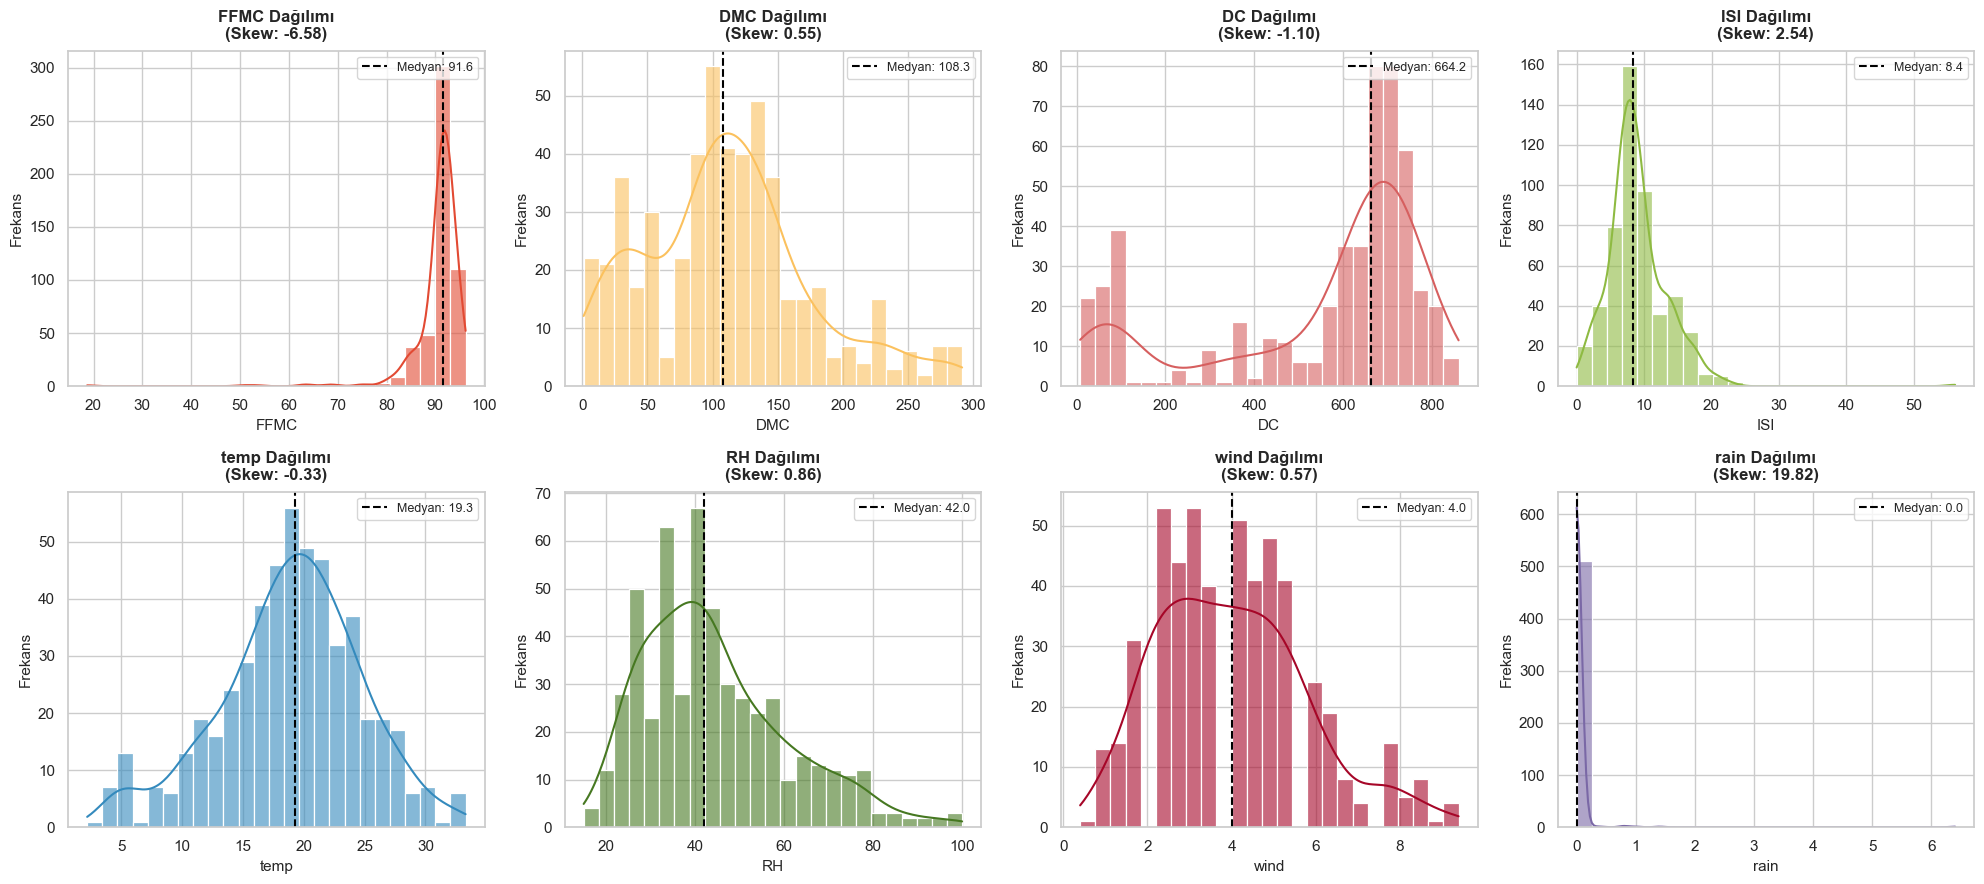

In [38]:
fwi_degiskenleri = ['FFMC', 'DMC', 'DC', 'ISI']
meteo_degiskenleri = ['temp', 'RH', 'wind', 'rain']
tum_sayisallar = fwi_degiskenleri + meteo_degiskenleri

anatomik_ozet = pd.DataFrame(
    {
        'Değişken': tum_sayisallar,
        'Grup': ['FWI Endeksi'] * 4 + ['Meteoroloji'] * 4,
        'Ortalama': [df[col].mean() for col in tum_sayisallar],
        'Medyan': [df[col].median() for col in tum_sayisallar],
        'Std Sapma': [df[col].std() for col in tum_sayisallar],
        'Min': [df[col].min() for col in tum_sayisallar],
        'Maks': [df[col].max() for col in tum_sayisallar],
        'Çarpıklık (Skewness)': [df[col].skew() for col in tum_sayisallar],
    }
)


def carpiklik_yorumla(skew_val):
    if skew_val < -1.0:
        return 'Sola Aşırı Çarpık (Left-Skewed)'
    elif skew_val > 1.0:
        return 'Sağa Aşırı Çarpık (Right-Skewed)'
    elif -0.5 <= skew_val <= 0.5:
        return 'Neredeyse Simetrik / Normal'
    else:
        return 'Hafif Çarpık'


anatomik_ozet['Dağılım Karakteri'] = anatomik_ozet['Çarpıklık (Skewness)'].apply(
    carpiklik_yorumla
)

print('--- 8 SAYISAL DEĞİŞKENİN ÖZETİ ---')
display(anatomik_ozet.round(2).T)

sns.set_theme(style='whitegrid', palette='deep')
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

fwi_renkler = ['#E24A33', '#FBC15E', '#D65F5F', '#8EBA42']
meteo_renkler = ['#348ABD', '#467821', '#A60628', '#7A68A6']

for i, col in enumerate(fwi_degiskenleri):
    sns.histplot(
        df[col],
        kde=True,
        color=fwi_renkler[i],
        ax=axes[0, i],
        bins=25,
        edgecolor='white',
        alpha=0.6,
    )
    axes[0, i].set_title(
        f'{col} Dağılımı\n(Skew: {df[col].skew():.2f})',
        fontsize=12,
        fontweight='bold',
        pad=8,
    )
    axes[0, i].set_xlabel(col, fontsize=11)
    axes[0, i].set_ylabel('Frekans', fontsize=11)

    medyan_val = df[col].median()
    axes[0, i].axvline(
        medyan_val,
        color='black',
        linestyle='--',
        linewidth=1.5,
        label=f'Medyan: {medyan_val:.1f}',
    )
    axes[0, i].legend(loc='upper right', fontsize=9)

for i, col in enumerate(meteo_degiskenleri):
    sns.histplot(
        df[col],
        kde=True,
        color=meteo_renkler[i],
        ax=axes[1, i],
        bins=25,
        edgecolor='white',
        alpha=0.6,
    )
    axes[1, i].set_title(
        f'{col} Dağılımı\n(Skew: {df[col].skew():.2f})',
        fontsize=12,
        fontweight='bold',
        pad=8,
    )
    axes[1, i].set_xlabel(col, fontsize=11)
    axes[1, i].set_ylabel('Frekans', fontsize=11)

    medyan_val = df[col].median()
    axes[1, i].axvline(
        medyan_val,
        color='black',
        linestyle='--',
        linewidth=1.5,
        label=f'Medyan: {medyan_val:.1f}',
    )
    axes[1, i].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

,nem_bolgesi,toplam_gun,yanginli_gun,yangin_olasiligi,toplam_yanan_alan,ort_yanan_alan,maks_yanan_alan
0,1. Diğer Durumlar (Nemli),55,27,49.09,334.24,12.38,51.78
1,2. Kuru Yüzey / Nemli Toprak,93,41,44.09,937.65,22.87,278.53
2,3. Nemli Yüzey / Kuru Toprak,16,10,62.50,207.95,20.80,105.66
3,4. Kuru Yüzey / Kuru Toprak,353,192,54.39,5162.21,26.89,1090.84


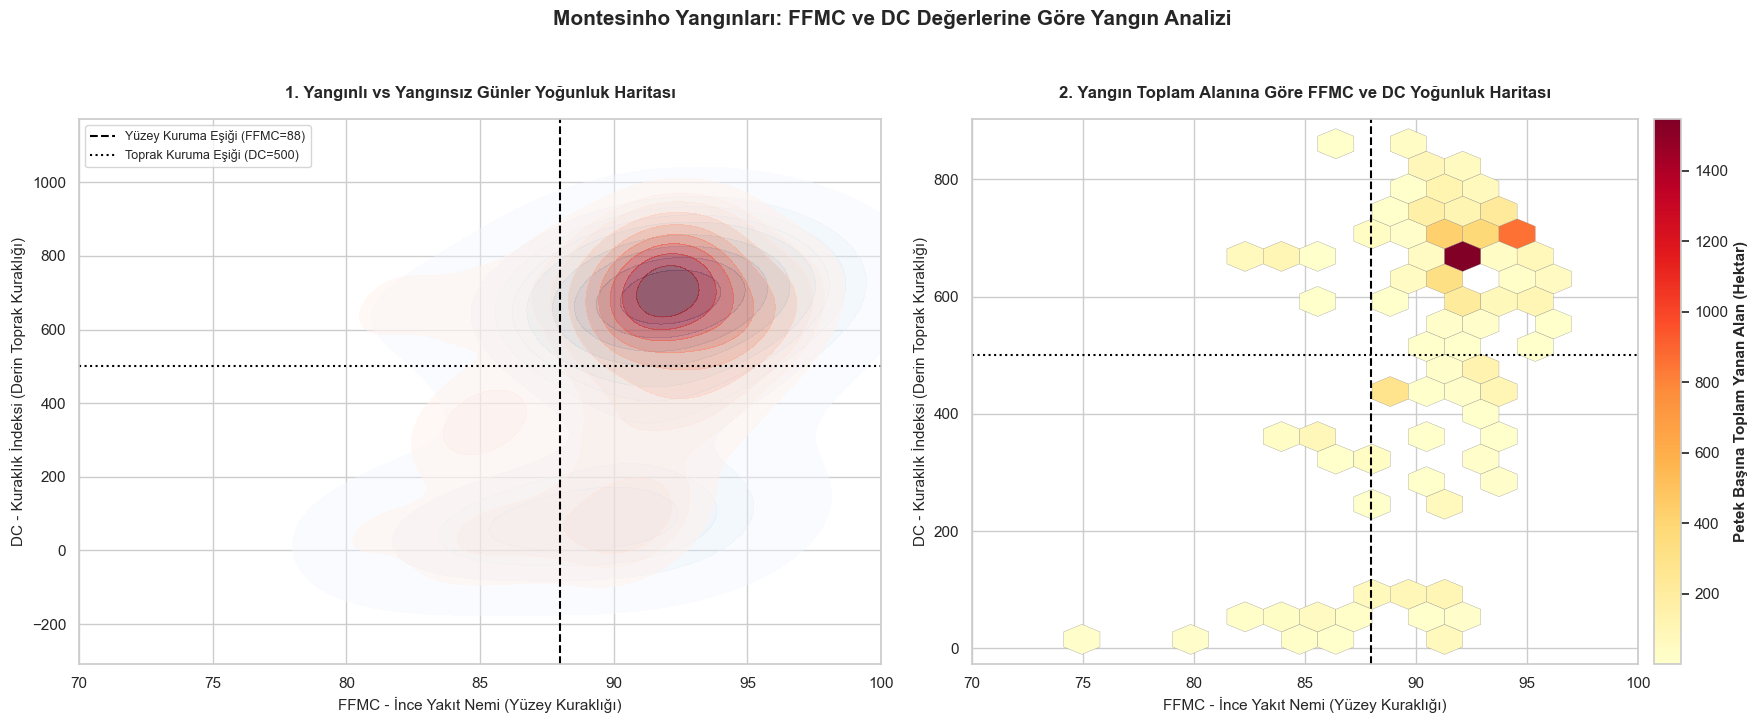

--- ORMANCILIK NEM ÜÇGENİ BİLİMSEl SONUÇLARI ---
4. Kuru Yüzey / Kuru Toprak (FFMC >= 88 & DC >= 500) Toplam Gün: 353
Bu Bölgedeki Yangın Olasılığı: %54.39 | Toplam Yanan Alan: 5162.21 hektar!
Diğer Tüm Bölgelerin Toplam Yanan Alanı: 1479.84 hektar


In [64]:
df['nem_bolgesi'] = '1. Diğer Durumlar (Nemli)'
df.loc[
    (df['FFMC'] >= 88.0) & (df['DC'] < 500.0), 'nem_bolgesi'
] = '2. Kuru Yüzey / Nemli Toprak'
df.loc[
    (df['FFMC'] < 88.0) & (df['DC'] >= 500.0), 'nem_bolgesi'
] = '3. Nemli Yüzey / Kuru Toprak'
df.loc[
    (df['FFMC'] >= 88.0) & (df['DC'] >= 500.0), 'nem_bolgesi'
] = '4. Kuru Yüzey / Kuru Toprak'

nem_ozeti = (
    df.groupby('nem_bolgesi', observed=True)
    .agg(
        toplam_gun=('area', 'count'),
        yanginli_gun=('area', lambda x: (x > 0).sum()),
        yangin_olasiligi=('area', lambda x: (x > 0).mean() * 100),
        toplam_yanan_alan=('area', 'sum'),
        ort_yanan_alan=('area', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
        maks_yanan_alan=('area', 'max'),
    )
    .reset_index()
)

display(nem_ozeti.round(2))

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.kdeplot(
    data=df[df['area'] == 0],
    x='FFMC',
    y='DC',
    cmap='Blues',
    fill=True,
    alpha=0.4,
    thresh=0.05,
    ax=axes[0],
    label='Yangınsız Günler (Mavi)',
)
sns.kdeplot(
    data=df[df['area'] > 0],
    x='FFMC',
    y='DC',
    cmap='Reds',
    fill=True,
    alpha=0.5,
    thresh=0.05,
    ax=axes[0],
    label='Yangınlı Günler (Kırmızı)',
)

axes[0].axvline(
    88.0,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Yüzey Kuruma Eşiği (FFMC=88)',
)
axes[0].axhline(
    500.0,
    color='black',
    linestyle=':',
    linewidth=1.5,
    label='Toprak Kuruma Eşiği (DC=500)',
)

axes[0].set_title(
    '1. Yangınlı vs Yangınsız Günler Yoğunluk Haritası',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[0].set_xlabel('FFMC - İnce Yakıt Nemi (Yüzey Kuraklığı)', fontsize=11)
axes[0].set_ylabel('DC - Kuraklık İndeksi (Derin Toprak Kuraklığı)', fontsize=11)
axes[0].legend(loc='upper left', frameon=True, fontsize=9)
axes[0].set_xlim(70, 100)  # Verinin odaklandığı ana aralık

yanginlar = df[df['area'] > 0]
hb = axes[1].hexbin(
    yanginlar['FFMC'],
    yanginlar['DC'],
    C=yanginlar['area'],
    reduce_C_function=np.sum,
    gridsize=20,
    cmap='YlOrRd',
    mincnt=1,
    edgecolors='grey',
    linewidths=0.2,
)

axes[1].axvline(88.0, color='black', linestyle='--', linewidth=1.5)
axes[1].axhline(500.0, color='black', linestyle=':', linewidth=1.5)

axes[1].set_title(
    '2. Yangın Toplam Alanına Göre FFMC ve DC Yoğunluk Haritası',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('FFMC - İnce Yakıt Nemi (Yüzey Kuraklığı)', fontsize=11)
axes[1].set_ylabel('DC - Kuraklık İndeksi (Derin Toprak Kuraklığı)', fontsize=11)
axes[1].set_xlim(70, 100)

cbar = fig.colorbar(hb, ax=axes[1], pad=0.02)
cbar.set_label('Petek Başına Toplam Yanan Alan (Hektar)', fontsize=11, fontweight='bold')

plt.suptitle(
    'Montesinho Yangınları: FFMC ve DC Değerlerine Göre Yangın Analizi',
    fontsize=15,
    fontweight='bold',
    y=1.03,
)
plt.tight_layout()
plt.show()

cifte_kuraklik = nem_ozeti.loc[
    nem_ozeti['nem_bolgesi'] == '4. Kuru Yüzey / Kuru Toprak'
]
diger_bolgeler = nem_ozeti.loc[
    nem_ozeti['nem_bolgesi'] != '4. Kuru Yüzey / Kuru Toprak'
]
print('--- ORMANCILIK NEM ÜÇGENİ BİLİMSEl SONUÇLARI ---')
print(
    f"4. Kuru Yüzey / Kuru Toprak (FFMC >= 88 & DC >= 500) Toplam Gün: {int(cifte_kuraklik['toplam_gun'].values[0])}"
)
print(
    f"Bu Bölgedeki Yangın Olasılığı: %{cifte_kuraklik['yangin_olasiligi'].values[0]:.2f} | Toplam Yanan Alan: {cifte_kuraklik['toplam_yanan_alan'].values[0]:.2f} hektar!"
)
print(
    f"Diğer Tüm Bölgelerin Toplam Yanan Alanı: {diger_bolgeler['toplam_yanan_alan'].sum():.2f} hektar"
)

In [69]:
hava_degiskenleri = [
    'month',
    'day',
    'FFMC',
    'DMC',
    'DC',
    'ISI',
    'temp',
    'RH',
    'wind',
    'rain',
]
es_zamanli_gruplar = df.groupby(hava_degiskenleri, observed=True).filter(
    lambda x: len(x) > 1
)

print(
    f'aynı gün yaşanmış toplam kayıt sayısı: {len(es_zamanli_gruplar)}'
)
print(
    f'Bu kayıtların aslında oluşturduğu benzersiz gün sayısı          : {df[hava_degiskenleri].drop_duplicates().shape[0]}'
)

en_kalabalik_gun = (
    es_zamanli_gruplar.groupby(hava_degiskenleri, observed=True)
    .size()
    .idxmax()
)
en_kalabalik_kayitlar = df[
    (df['month'] == en_kalabalik_gun[0])
    & (df['day'] == en_kalabalik_gun[1])
    & (df['temp'] == en_kalabalik_gun[6])
]

print(
    f'Tarih: {str(en_kalabalik_gun[0]).upper()} ayı, {str(en_kalabalik_gun[1]).upper()} günü | Sıcaklık: {en_kalabalik_gun[6]}°C | Nem: %{en_kalabalik_gun[7]}'
)
print(
    f'➡️ O gün parkın {len(en_kalabalik_kayitlar)} farklı noktasında aynı anda yangın kaydı girilmiş'
)

print('Aynı öğleden sonra farklı koordinatlarda çıkan yangınların listesi:')
display(en_kalabalik_kayitlar[['X', 'Y', 'temp', 'RH', 'wind', 'area']])

aynı gün yaşanmış toplam kayıt sayısı: 62
Bu kayıtların aslında oluşturduğu benzersiz gün sayısı          : 484
Tarih: DEC ayı, MON günü | Sıcaklık: 4.6°C | Nem: %21
➡️ O gün parkın 4 farklı noktasında aynı anda yangın kaydı girilmiş
Aynı öğleden sonra farklı koordinatlarda çıkan yangınların listesi:


,X,Y,temp,RH,wind,area
276,4,4,4.6,21,8.5,17.85
277,3,4,4.6,21,8.5,10.73
278,4,4,4.6,21,8.5,22.03
279,4,4,4.6,21,8.5,9.77


In [71]:
hava_degiskenleri = [
    'month',
    'day',
    'FFMC',
    'DMC',
    'DC',
    'ISI',
    'temp',
    'RH',
    'wind',
    'rain',
]
es_zamanli_df = (
    df.groupby(hava_degiskenleri, observed=True)
    .filter(lambda x: len(x) > 1)
    .copy()
)

def max_mesafe_bul(grup):
    coords = grup[['X', 'Y']].values
    if len(coords) < 2:
        return 0.0
    mesafeler = []
    for i in range(len(coords)):
        for j in range(i + 1, len(coords)):
            dist = np.sqrt(
                (coords[i][0] - coords[j][0]) ** 2
                + (coords[i][1] - coords[j][1]) ** 2
            )
            mesafeler.append(dist)
    return max(mesafeler) if mesafeler else 0.0

kume_ozeti = (
    es_zamanli_df.groupby(hava_degiskenleri, observed=True)
    .apply(
        lambda g: pd.Series(
            {
                'odak_sayisi': len(g),
                'max_mesafe': max_mesafe_bul(g),
                'gun': g['day'].iloc[0],
                'toplam_alan': g['area'].sum(),
            }
        )
    )
    .reset_index()
)

kume_ozeti['tatil_mi'] = kume_ozeti['gun'].isin(['fri', 'sat', 'sun']).map(
    {True: 'Hafta Sonu Bloğu (Cuma-Paz)', False: 'Hafta İçi (Pzt-Prş)'}
)

kume_ozeti['mesafe_turu'] = np.where(
    kume_ozeti['max_mesafe'] < 2.5,
    'Yakın (<2.5 br - Rüzgarla Sıçrama)',
    'Uzak (>=2.5 br - Çoklu Piknik/İhmal)',
)

display(
    kume_ozeti.groupby(['tatil_mi', 'mesafe_turu'], observed=True)
    .agg(
        kume_sayisi=('odak_sayisi', 'count'),
        ort_odak_sayisi=('odak_sayisi', 'mean'),
        ort_mesafe=('max_mesafe', 'mean'),
        ort_toplam_alan=('toplam_alan', 'mean'),
    )
    .round(2)
)

print('\nÖrnek: Parkın birbirine en uzak noktalarında aynı anda yangın çıkan gün:')
en_uzak_kume = kume_ozeti.sort_values(by='max_mesafe', ascending=False).iloc[0]
print(
    f"Tarih: {str(en_uzak_kume['month']).upper()} ayı, {str(en_uzak_kume['gun']).upper()} günü ({en_uzak_kume['tatil_mi']})"
)
print(
    f"Aynı saatte çıkan yangınlar arasındaki mesafe tam {en_uzak_kume['max_mesafe']:.2f} birim (kilometrelerce uzak)!"
)

kume_sayisi  \
tatil_mi                    mesafe_turu                                         
Hafta Sonu Bloğu (Cuma-Paz) Uzak (>=2.5 br - Çoklu Piknik/İhmal)            5   
                            Yakın (<2.5 br - Rüzgarla Sıçrama)             10   
Hafta İçi (Pzt-Prş)         Uzak (>=2.5 br - Çoklu Piknik/İhmal)            7   
                            Yakın (<2.5 br - Rüzgarla Sıçrama)              7   

                                                                  ort_odak_sayisi  \
tatil_mi                    mesafe_turu                                             
Hafta Sonu Bloğu (Cuma-Paz) Uzak (>=2.5 br - Çoklu Piknik/İhmal)             2.20   
                            Yakın (<2.5 br - Rüzgarla Sıçrama)               2.00   
Hafta İçi (Pzt-Prş)         Uzak (>=2.5 br - Çoklu Piknik/İhmal)             2.14   
                            Yakın (<2.5 br - Rüzgarla Sıçrama)               2.29   

                                                                  ort_mesafe  \
tatil_mi                    mesafe_turu                                        
Hafta Sonu Bloğu (Cuma-Paz) Uzak (>=2.5 br - Çoklu Piknik/İhmal)        4.92   
                            Yakın (<2.5 br - Rüzgarla Sıçrama)          0.75   
Hafta İçi (Pzt-Prş)         Uzak (>=2.5 br - Çoklu Piknik/İhmal)        5.15   
                            Yakın (<2.5 br - Rüzgarla Sıçrama)          0.66   

                                                                  ort_toplam_alan  
tatil_mi                    mesafe_turu                                            
Hafta Sonu Bloğu (Cuma-Paz) Uzak (>=2.5 br - Çoklu Piknik/İhmal)            10.15  
                            Yakın (<2.5 br - Rüzgarla Sıçrama)              14.00  
Hafta İçi (Pzt-Prş)         Uzak (>=2.5 br - Çoklu Piknik/İhmal)            13.56  
                            Yakın (<2.5 br - Rüzgarla Sıçrama)              27.33


Örnek: Parkın birbirine en uzak noktalarında aynı anda yangın çıkan gün:
Tarih: AUG ayı, THU günü (Hafta İçi (Pzt-Prş))
Aynı saatte çıkan yangınlar arasındaki mesafe tam 7.21 birim (kilometrelerce uzak)!


In [72]:
hava_degiskenleri = [
    'month',
    'day',
    'FFMC',
    'DMC',
    'DC',
    'ISI',
    'temp',
    'RH',
    'wind',
    'rain',
]
gunluk_gercek_afet = (
    df.groupby(hava_degiskenleri, observed=True)
    .agg(
        gunluk_toplam_alan=('area', 'sum'),
        odak_sayisi=('area', 'count'),
        en_buyuk_tek_odak=('area', 'max'),
    )
    .reset_index()
)

print(f'Veri setindeki toplam satır sayısı         : {len(df)}')
print(f'Gerçekte yaşanmış benzersiz gün sayısı     : {len(gunluk_gercek_afet)}')
print(
    f"En büyük tek satırlık yangın (makalelere göre): {df['area'].max():.2f} hektar"
)
print(
    f"Gerçekte bir günde yanan en büyük toplam alan : {gunluk_gercek_afet['gunluk_toplam_alan'].max():.2f} hektar!"
)

gizli_buyuk_afetler = gunluk_gercek_afet[
    (gunluk_gercek_afet['en_buyuk_tek_odak'] <= 50)
    & (gunluk_gercek_afet['gunluk_toplam_alan'] > 50)
]

print(f'BUYUK-AFET GÜNLERİ SAYISI: {len(gizli_buyuk_afetler)} gün!')
if len(gizli_buyuk_afetler) > 0:
    display(
        gizli_buyuk_afetler[
            [
                'month',
                'day',
                'temp',
                'RH',
                'wind',
                'odak_sayisi',
                'en_buyuk_tek_odak',
                'gunluk_toplam_alan',
            ]
        ]
    )
else:
    print(
        '\nEn çok tahribat bırakan birleşen yangın günlerinin listesi:'
    )
    display(
        gunluk_gercek_afet[gunluk_gercek_afet['odak_sayisi'] > 1]
        .sort_values(by='gunluk_toplam_alan', ascending=False)
        .head(5)[
            [
                'month',
                'day',
                'temp',
                'RH',
                'wind',
                'odak_sayisi',
                'en_buyuk_tek_odak',
                'gunluk_toplam_alan',
            ]
        ]
    )

Veri setindeki toplam satır sayısı         : 517
Gerçekte yaşanmış benzersiz gün sayısı     : 484
En büyük tek satırlık yangın (makalelere göre): 1090.84 hektar
Gerçekte bir günde yanan en büyük toplam alan : 1090.84 hektar!
BUYUK-AFET GÜNLERİ SAYISI: 3 gün!


,month,day,temp,RH,wind,odak_sayisi,en_buyuk_tek_odak,gunluk_toplam_alan
27,mar,mon,11.0,46,5.8,3,36.85,64.20
64,mar,sat,17.0,27,4.9,2,28.66,57.32
478,dec,mon,4.6,21,8.5,4,22.03,60.38


In [74]:
hava_degiskenleri = [
    'month',
    'day',
    'FFMC',
    'DMC',
    'DC',
    'ISI',
    'temp',
    'RH',
    'wind',
    'rain',
]
gunluk_karsilastirma = (
    df.groupby(hava_degiskenleri, observed=True)
    .agg(
        odak_sayisi=('area', 'count'),
        gunluk_toplam_alan=('area', 'sum'),
        ort_temp=('temp', 'mean'),
        ort_RH=('RH', 'mean'),
        ort_wind=('wind', 'mean'),
        ort_FFMC=('FFMC', 'mean'),
        ort_DC=('DC', 'mean'),
        ort_ISI=('ISI', 'mean'),
    )
    .reset_index()
)

gunluk_karsilastirma['gun_turu'] = gunluk_karsilastirma['odak_sayisi'].apply(
    lambda x: '1. Tek Odaklı Gün (1 Yangın)'
    if x == 1
    else '2. Çoklu Odaklı Gün (>=2 Yangın)'
)

sifre_tablosu = (
    gunluk_karsilastirma.groupby('gun_turu', observed=True)
    .agg(
        toplam_gun=('odak_sayisi', 'count'),
        ort_odak_sayisi=('odak_sayisi', 'mean'),
        ort_sicaklik_temp=('ort_temp', 'mean'),
        ort_nem_RH=('ort_RH', 'mean'),
        ort_ruzgar_wind=('ort_wind', 'mean'),
        ort_yuzey_nemi_FFMC=('ort_FFMC', 'mean'),
        ort_toprak_kurakligi_DC=('ort_DC', 'mean'),
        ort_yayilma_hizi_ISI=('ort_ISI', 'mean'),
        ort_gunluk_alan=('gunluk_toplam_alan', 'mean'),
    )
    .reset_index()
)

display(sifre_tablosu.round(2))

tekli = sifre_tablosu.iloc[0]
coklu = sifre_tablosu.iloc[1]

print(
    f"Rüzgar Farkı  : Tekli günlerde {tekli['ort_ruzgar_wind']:.2f} km/s iken, Çoklu günlerde {coklu['ort_ruzgar_wind']:.2f} km/s!"
)
print(
    f"ISI (Yayılma) : Tekli günlerde {tekli['ort_yayilma_hizi_ISI']:.2f} iken, Çoklu günlerde {coklu['ort_yayilma_hizi_ISI']:.2f} seviyesine çıkmış!"
)
print(
    f"Günlük Yıkım  : Tek Odaklı günlerde ortalama {tekli['ort_gunluk_alan']:.2f} hektar yanarken,"
)
print(
    f"Çoklu Odaklı günlerde tahribat {coklu['ort_gunluk_alan']:.2f} hektara fırlamıştır!"
)

,gun_turu,toplam_gun,ort_odak_sayisi,ort_sicaklik_temp,ort_nem_RH,ort_ruzgar_wind,ort_yuzey_nemi_FFMC,ort_toprak_kurakligi_DC,ort_yayilma_hizi_ISI,ort_gunluk_alan
0,1. Tek Odaklı Gün (1 Yangın),455,1.00,19.04,44.59,3.93,90.56,545.00,9.04,13.55
1,2. Çoklu Odaklı Gün (>=2 Yangın),29,2.14,18.30,42.38,4.52,91.49,582.63,9.21,16.45


Rüzgar Farkı  : Tekli günlerde 3.93 km/s iken, Çoklu günlerde 4.52 km/s!
ISI (Yayılma) : Tekli günlerde 9.04 iken, Çoklu günlerde 9.21 seviyesine çıkmış!
Günlük Yıkım  : Tek Odaklı günlerde ortalama 13.55 hektar yanarken,
Çoklu Odaklı günlerde tahribat 16.45 hektara fırlamıştır!


In [76]:
# Gözden kaçırdığımız o net toplamı hemen basalım:
tekli_toplam = gunluk_karsilastirma[gunluk_karsilastirma['odak_sayisi'] == 1][
    'gunluk_toplam_alan'
].sum()
coklu_toplam = gunluk_karsilastirma[gunluk_karsilastirma['odak_sayisi'] > 1][
    'gunluk_toplam_alan'
].sum()

print('--- AYNI GÜN ÇIKAN YANGINLARIN TOPLAM YIKIM KANITI ---')
print(
    f'Parkta 4 yılda yanan TOPLAM ALAN              : {df["area"].sum():.2f} hektar'
)
print(
    f'Tek bir yangın çıkan günlerde yanan toplam alan : {tekli_toplam:.2f} hektar'
)
print(
    f'Aynı gün ÇOKLU yangın çıkan günlerde yanan alan : {coklu_toplam:.2f} hektar!'
)
print(
    f'SONUÇ: Çoklu yangın günleri verinin sadece %6 sını oluştursa da,'
)
print(
    f'   toplam tahribatın %{coklu_toplam / df["area"].sum() * 100:.1f} sini tek başına gerçekleştirmiştir!'
)

--- AYNI GÜN ÇIKAN YANGINLARIN TOPLAM YIKIM KANITI ---
Parkta 4 yılda yanan TOPLAM ALAN              : 6642.05 hektar
Tek bir yangın çıkan günlerde yanan toplam alan : 6165.12 hektar
Aynı gün ÇOKLU yangın çıkan günlerde yanan alan : 476.93 hektar!
SONUÇ: Çoklu yangın günleri verinin sadece %6 sını oluştursa da,
   toplam tahribatın %7.2 sini tek başına gerçekleştirmiştir!


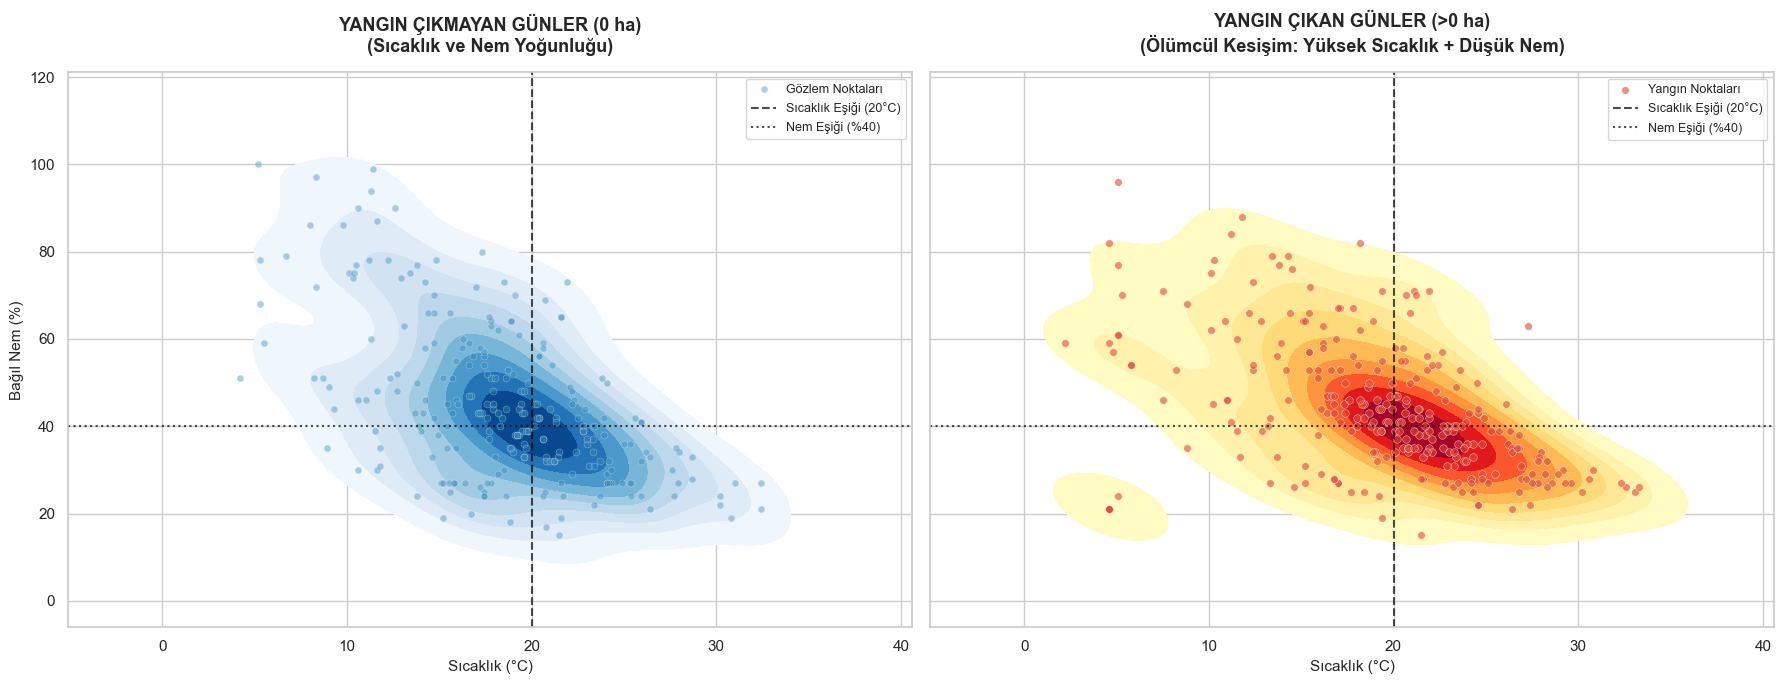

,Meteorolojik Durum,Toplam Gün Sayısı,Yangın Çıkma Olasılığı (%),Yangın Başına Ortalama Alan (ha),Toplam Yanan Alan (ha)
0,Sıcaklık >= 20°C & Nem <= %40,160,60.0,34.29,3291.37
1,Daha serin ve Nemli Diğer Koşullar,357,48.7,19.26,3350.68


In [40]:
df['yangin_durumu'] = df['area'].apply(
    lambda x: 'Yangın Var (>0 ha)' if x > 0 else 'Yangın Yok (0 ha)'
)
yangin_var = df[df['area'] > 0]
yangin_yok = df[df['area'] == 0]

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True, sharey=True)

sns.kdeplot(
    data=yangin_yok,
    x='temp',
    y='RH',
    fill=True,
    cmap='Blues',
    thresh=0.05,
    levels=10,
    ax=axes[0],
)
sns.scatterplot(
    data=yangin_yok,
    x='temp',
    y='RH',
    color='#348ABD',
    alpha=0.4,
    s=25,
    ax=axes[0],
    label='Gözlem Noktaları',
)
axes[0].set_title(
    'YANGIN ÇIKMAYAN GÜNLER (0 ha)\n(Sıcaklık ve Nem Yoğunluğu)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
axes[0].set_xlabel('Sıcaklık (°C)', fontsize=11)
axes[0].set_ylabel('Bağıl Nem (%)', fontsize=11)

sns.kdeplot(
    data=yangin_var,
    x='temp',
    y='RH',
    fill=True,
    cmap='YlOrRd',
    thresh=0.05,
    levels=10,
    ax=axes[1],
)
sns.scatterplot(
    data=yangin_var,
    x='temp',
    y='RH',
    color='#E24A33',
    alpha=0.6,
    s=30,
    ax=axes[1],
    label='Yangın Noktaları',
)
axes[1].set_title(
    'YANGIN ÇIKAN GÜNLER (>0 ha)\n(Ölümcül Kesişim: Yüksek Sıcaklık + Düşük Nem)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('Sıcaklık (°C)', fontsize=11)
axes[1].set_ylabel('Bağıl Nem (%)', fontsize=11)

for ax in axes:
    ax.axvline(
        20,
        color='black',
        linestyle='--',
        linewidth=1.5,
        alpha=0.7,
        label='Sıcaklık Eşiği (20°C)',
    )
    ax.axhline(
        40,
        color='black',
        linestyle=':',
        linewidth=1.5,
        alpha=0.7,
        label='Nem Eşiği (%40)',
    )
    ax.legend(loc='upper right', frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

tehlikeli_bolge = df[(df['temp'] >= 20) & (df['RH'] <= 40)]
guvenli_bolge = df[~((df['temp'] >= 20) & (df['RH'] <= 40))]

tehlikeli_yangin_orani = (tehlikeli_bolge['area'] > 0).mean() * 100
guvenli_yangin_orani = (guvenli_bolge['area'] > 0).mean() * 100

tehlikeli_ort_alan = tehlikeli_bolge[tehlikeli_bolge['area'] > 0]['area'].mean()
guvenli_ort_alan = guvenli_bolge[guvenli_bolge['area'] > 0]['area'].mean()

kesisim_ozeti = pd.DataFrame(
    {
        'Meteorolojik Durum': [
            'Sıcaklık >= 20°C & Nem <= %40',
            'Daha serin ve Nemli Diğer Koşullar',
        ],
        'Toplam Gün Sayısı': [len(tehlikeli_bolge), len(guvenli_bolge)],
        'Yangın Çıkma Olasılığı (%)': [
            round(tehlikeli_yangin_orani, 1),
            round(guvenli_yangin_orani, 1),
        ],
        'Yangın Başına Ortalama Alan (ha)': [
            round(tehlikeli_ort_alan, 2),
            round(guvenli_ort_alan, 2),
        ],
        'Toplam Yanan Alan (ha)': [
            round(tehlikeli_bolge['area'].sum(), 2),
            round(guvenli_bolge['area'].sum(), 2),
        ],
    }
)

display(kesisim_ozeti)

Toplam 509 gününde (%98.5) yağmur 0.0 
 8 günde (%1.5) yağmur yağmış.


,499,509,243,500,501,502,3,286
month,aug,aug,aug,aug,aug,aug,mar,jul
day,tue,fri,sun,tue,tue,tue,fri,wed
temp,27.3,21.1,21.9,21.6,21.6,20.7,8.3,12.6
RH,63,71,73,65,65,69,97,90
wind,4.9,7.6,7.6,4.9,4.9,4.9,4.0,7.6
rain,6.4,1.4,1.0,0.8,0.8,0.4,0.2,0.2
area,10.82,2.17,0.0,0.0,0.0,0.0,0.0,0.0


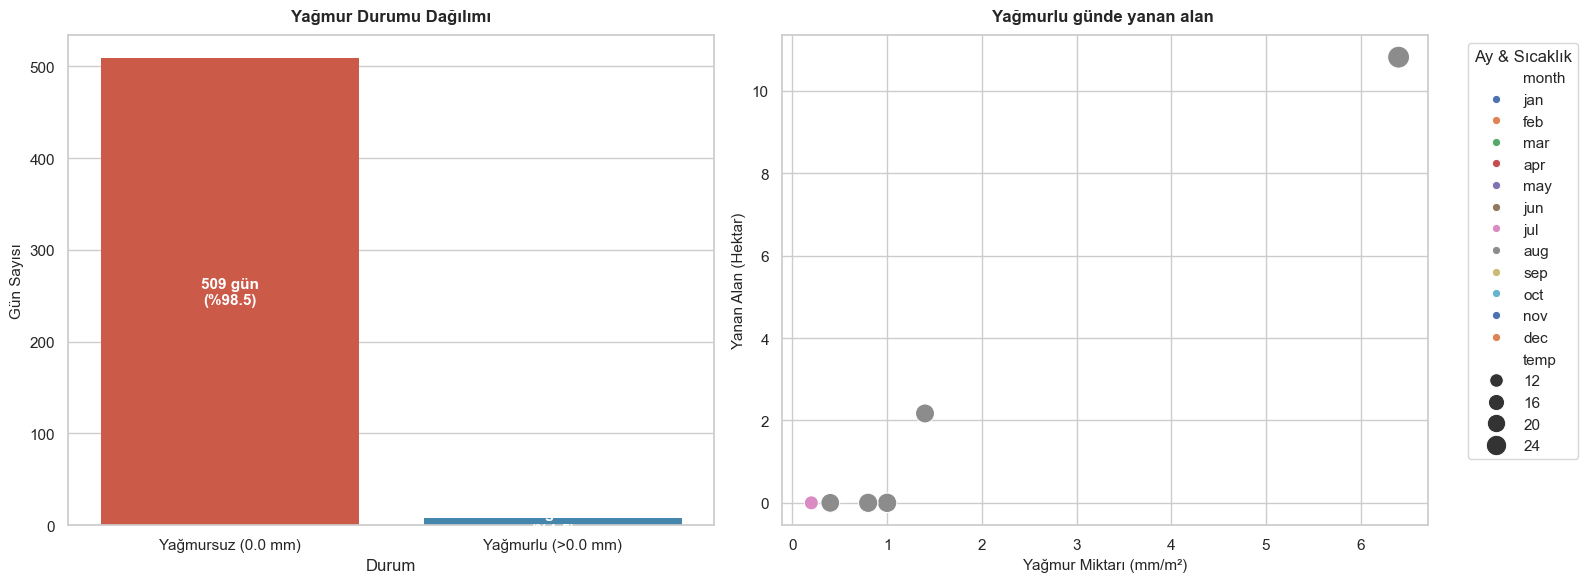

In [43]:
yagmurlu_gunler = df[df['rain'] > 0].copy()
yagmursuz_gunler = df[df['rain'] == 0].copy()

toplam_gun = len(df)
yagmursuz_sayisi = len(yagmursuz_gunler)
yagmurlu_sayisi = len(yagmurlu_gunler)
yagmursuz_oran = (yagmursuz_sayisi / toplam_gun) * 100


print(f'Toplam {yagmursuz_sayisi} gününde (%{yagmursuz_oran:.1f}) yağmur 0.0 ')
print(f' {yagmurlu_sayisi} günde (%{100-yagmursuz_oran:.1f}) yağmur yağmış.')

yagmurlu_tablo = yagmurlu_gunler[
    ['month', 'day', 'temp', 'RH', 'wind', 'rain', 'area']
].sort_values(by='rain', ascending=False)
display(yagmurlu_tablo.T)

sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

durum_sayilari = pd.DataFrame(
    {
        'Durum': ['Yağmursuz (0.0 mm)', 'Yağmurlu (>0.0 mm)'],
        'Gün Sayısı': [yagmursuz_sayisi, yagmurlu_sayisi],
    }
)
sns.barplot(
    data=durum_sayilari,
    x='Durum',
    y='Gün Sayısı',
    palette=['#E24A33', '#348ABD'],
    ax=axes[0],
    edgecolor='none',
)
axes[0].set_title(
    f'Yağmur Durumu Dağılımı',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[0].set_ylabel('Gün Sayısı', fontsize=11)

for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(
        f'{int(height)} gün\n(%{height/toplam_gun*100:.1f})',
        (p.get_x() + p.get_width() / 2.0, height / 2),
        ha='center',
        va='center',
        fontsize=11,
        color='white',
        fontweight='bold',
    )

sns.scatterplot(
    data=yagmurlu_tablo,
    x='rain',
    y='area',
    hue='month',
    size='temp',
    sizes=(60, 250),
    palette='deep',
    ax=axes[1],
)
axes[1].set_title(
    'Yağmurlu günde yanan alan ',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[1].set_xlabel('Yağmur Miktarı (mm/m²)', fontsize=11)
axes[1].set_ylabel('Yanan Alan (Hektar)', fontsize=11)
axes[1].legend(title='Ay & Sıcaklık', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [6]:
yagmurlu_gunler = df[df['rain'] > 0]
kurak_gunler = df[df['rain'] == 0]

print(f'Toplam Kayıt Sayısı             : {len(df)}')
print(
    f'Hiç Yağmur Olmayan (0.0 mm) Gün : {len(kurak_gunler)} (Verinin %{len(kurak_gunler)/len(df)*100:.2f} si!)'
)
print(
    f'Yağmur Kaydı Olan (rain > 0) Gün: {len(yagmurlu_gunler)} (Verinin sadece %{len(yagmurlu_gunler)/len(df)*100:.2f} si!)'
)
print('----------------------------------------------------------------------------------')

display(
    yagmurlu_gunler[
        [
            'month',
            'day',
            'temp',
            'RH',
            'wind',
            'rain',
            'FFMC',
            'DMC',
            'area',
        ]
    ].sort_values(by='rain', ascending=False)
)

Toplam Kayıt Sayısı             : 517
Hiç Yağmur Olmayan (0.0 mm) Gün : 509 (Verinin %98.45 si!)
Yağmur Kaydı Olan (rain > 0) Gün: 8 (Verinin sadece %1.55 si!)
----------------------------------------------------------------------------------


,month,day,temp,RH,wind,rain,FFMC,DMC,area
499,aug,tue,27.3,63,4.9,6.4,96.1,181.1,10.82
509,aug,fri,21.1,71,7.6,1.4,91.0,166.9,2.17
243,aug,sun,21.9,73,7.6,1.0,91.8,175.1,0.00
500,aug,tue,21.6,65,4.9,0.8,96.1,181.1,0.00
501,aug,tue,21.6,65,4.9,0.8,96.1,181.1,0.00
502,aug,tue,20.7,69,4.9,0.4,96.1,181.1,0.00
3,mar,fri,8.3,97,4.0,0.2,91.7,33.3,0.00
286,jul,wed,12.6,90,7.6,0.2,91.2,183.1,0.00


VIF (VARIANCE INFLATION FACTOR) ÇOKLU DOĞRUSALLIK ANALİZİ


,Değişken,VIF Değeri,Risk Durumu
4,temp,2.66,Düşük Korelasyon
1,DMC,2.33,Düşük Korelasyon
2,DC,2.08,Düşük Korelasyon
5,RH,1.90,Düşük Korelasyon
0,FFMC,1.70,Düşük Korelasyon
3,ISI,1.58,Düşük Korelasyon
6,wind,1.14,Düşük Korelasyon
7,rain,1.04,Düşük Korelasyon


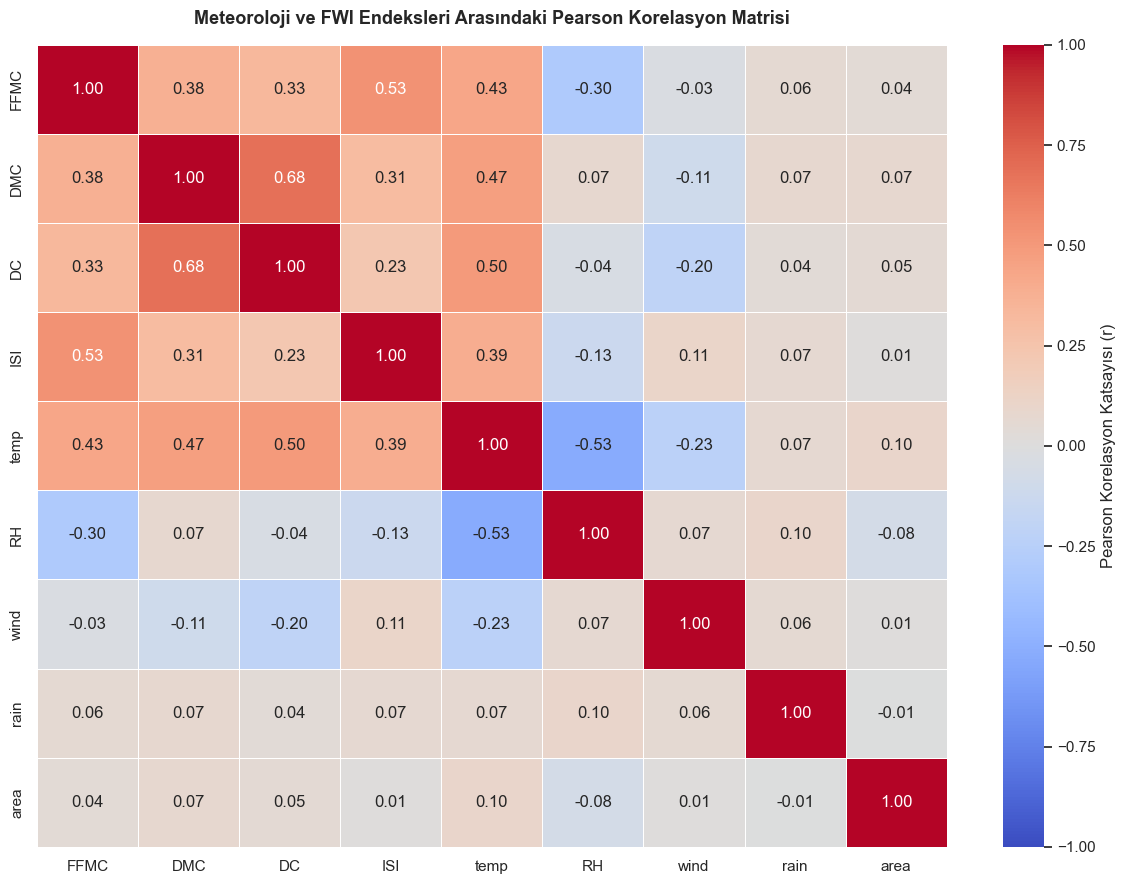

--- En yüksek 3 korelasyon ---
[DC <---> DMC] -> r = 0.68 (Güçlü Pozitif İlişki)
[FFMC <---> ISI] -> r = 0.53 (Güçlü Pozitif İlişki)
[temp <---> RH] -> r = -0.53 (Güçlü Negatif İlişki)


In [50]:
sayisal_degiskenler = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
korelasyon_degiskenleri = sayisal_degiskenler + ['area']
corr_matrix = df[korelasyon_degiskenleri].corr(method='pearson')

X_vif = add_constant(df[sayisal_degiskenler])
vif_veri = []

for i, col in enumerate(X_vif.columns):
    if col == 'const':
        continue 
    vif_degeri = variance_inflation_factor(X_vif.values, i)
    vif_veri.append({'Değişken': col, 'VIF Değeri': vif_degeri})

vif_tablosu = pd.DataFrame(vif_veri).sort_values(by='VIF Değeri', ascending=False)

def vif_risk_yorumla(vif):
    if vif > 10.0:
        return ' Aşırı doğrusal'
    elif vif > 5.0:
        return 'Yüksek Çoklu Doğrusallık'
    else:
        return 'Düşük Korelasyon'


vif_tablosu['Risk Durumu'] = vif_tablosu['VIF Değeri'].apply(vif_risk_yorumla)

print('=' * 80)
print('VIF (VARIANCE INFLATION FACTOR) ÇOKLU DOĞRUSALLIK ANALİZİ')
print('=' * 80)
display(vif_tablosu.round(2))

sns.set_theme(style='white')
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Korelasyon Katsayısı (r)'},
)

plt.title(
    'Meteoroloji ve FWI Endeksleri Arasındaki Pearson Korelasyon Matrisi',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.tight_layout()
plt.show()

unstacked = corr_matrix.abs().unstack()
sirali_korelasyonlar = unstacked[unstacked < 1.0].sort_values(ascending=False)
en_guclu_ciftler = sirali_korelasyonlar.drop_duplicates().head(3)

print('--- En yüksek 3 korelasyon ---')
for (col1, col2), val in en_guclu_ciftler.items():
    gercek_r = corr_matrix.loc[col1, col2]
    print(
        f'[{col1} <---> {col2}] -> r = {gercek_r:.2f} (Güçlü {"Pozitif" if gercek_r > 0 else "Negatif"} İlişki)'
    )

,ruzgar_kategorisi,toplam_gun,yanginli_gun,yangin_olasiligi,ort_yanan_alan,toplam_yanan_alan,maks_yanan_alan
0,Yavaş Rüzgar (0-3.5 km/s),209,104,49.76,19.64,2042.32,212.88
1,Orta Rüzgar (3.5-6.0 km/s),245,129,52.65,32.23,4157.89,1090.84
2,Fırtınamsı Rüzgar (>6.0 km/s),63,37,58.73,11.94,441.84,61.13


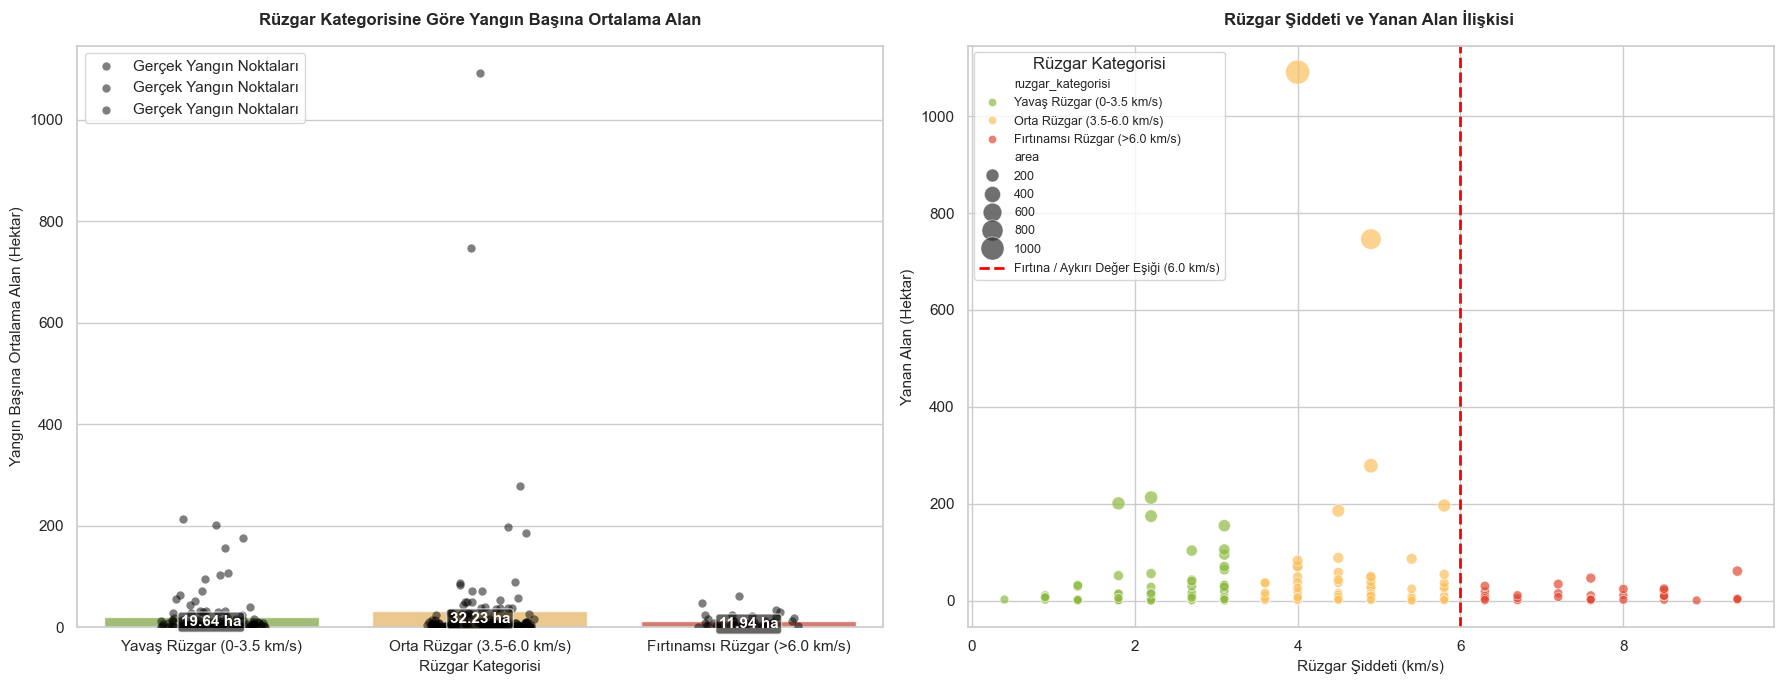

Rüzgar: 9.4 km/s | Tarih: [APR - SUN] | Sıcaklık: 13.7°C | Nem: %33 -> Yanan Alan: 61.13 hektar
Rüzgar: 7.6 km/s | Tarih: [AUG - TUE] | Sıcaklık: 19.4°C | Nem: %71 -> Yanan Alan: 46.7 hektar
Rüzgar: 7.2 km/s | Tarih: [SEP - THU] | Sıcaklık: 18.9°C | Nem: %34 -> Yanan Alan: 34.36 hektar
Rüzgar: 6.3 km/s | Tarih: [SEP - MON] | Sıcaklık: 12.4°C | Nem: %73 -> Yanan Alan: 30.32 hektar
Rüzgar: 8.5 km/s | Tarih: [DEC - TUE] | Sıcaklık: 5.1°C | Nem: %24 -> Yanan Alan: 24.77 hektar


In [52]:
ruzgar_sinirlari = [0, 3.5, 6.0, df['wind'].max() + 1]
ruzgar_isimleri = [
    'Yavaş Rüzgar (0-3.5 km/s)',
    'Orta Rüzgar (3.5-6.0 km/s)',
    'Fırtınamsı Rüzgar (>6.0 km/s)',
]
df['ruzgar_kategorisi'] = pd.cut(
    df['wind'], bins=ruzgar_sinirlari, labels=ruzgar_isimleri, right=False
)
ruzgar_ozeti = (
    df.groupby('ruzgar_kategorisi', observed=True)
    .agg(
        toplam_gun=('wind', 'count'),
        yanginli_gun=('area', lambda x: (x > 0).sum()),
        yangin_olasiligi=('area', lambda x: (x > 0).mean() * 100),
        ort_yanan_alan=('area', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
        toplam_yanan_alan=('area', 'sum'),
        maks_yanan_alan=('area', 'max'),
    )
    .reset_index()
)

display(ruzgar_ozeti.round(2))

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

yanginlar = df[df['area'] > 0].copy()

sns.barplot(
    data=yanginlar,
    x='ruzgar_kategorisi',
    y='area',
    estimator=np.mean,
    errorbar=None,
    palette=['#8EBA42', '#FBC15E', '#E24A33'],
    ax=axes[0],
    alpha=0.8,
)
sns.stripplot(
    data=yanginlar,
    x='ruzgar_kategorisi',
    y='area',
    color='black',
    alpha=0.5,
    jitter=0.2,
    size=6,
    ax=axes[0],
    label='Gerçek Yangın Noktaları',
)
axes[0].set_title(
    'Rüzgar Kategorisine Göre Yangın Başına Ortalama Alan',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[0].set_xlabel('Rüzgar Kategorisi', fontsize=11)
axes[0].set_ylabel('Yangın Başına Ortalama Alan (Hektar)', fontsize=11)
axes[0].legend(loc='upper left', frameon=True)

for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(
            f'{height:.2f} ha',
            (p.get_x() + p.get_width() / 2.0, height / 2),
            ha='center',
            va='center',
            fontsize=11,
            color='white',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6),
        )

sns.scatterplot(
    data=yanginlar,
    x='wind',
    y='area',
    hue='ruzgar_kategorisi',
    palette=['#8EBA42', '#FBC15E', '#E24A33'],
    size='area',
    sizes=(40, 300),
    alpha=0.7,
    ax=axes[1],
)
axes[1].axvline(
    6.0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Fırtına / Aykırı Değer Eşiği (6.0 km/s)',
)
axes[1].set_title(
    'Rüzgar Şiddeti ve Yanan Alan İlişkisi ',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('Rüzgar Şiddeti (km/s)', fontsize=11)
axes[1].set_ylabel('Yanan Alan (Hektar)', fontsize=11)
axes[1].legend(title='Rüzgar Kategorisi', loc='upper left', frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

firtinalar = df[df['wind'] >= 6.0].sort_values(by='area', ascending=False).head(5)
for idx, row in firtinalar.iterrows():
    print(
        f"Rüzgar: {row['wind']} km/s | Tarih: [{row['month'].upper()} - {row['day'].upper()}] | Sıcaklık: {row['temp']}°C | Nem: %{row['RH']} -> Yanan Alan: {row['area']} hektar"
    )

Parkta 4 Yılda Yanan Toplam Alan : 6642.05 hektar (517 kayıt)


,Dilim,Yangın Sayısı,Yaktığı Toplam Alan (ha),Tüm Yıkımdaki Payı (%),Ortalama Yangın Büyüklüğü (ha)
0,Top %1,5,2529.47,38.08,505.89
1,Top %5,25,4410.75,66.41,176.43
2,Top %10,51,5321.54,80.12,104.34
3,Top %20,103,6062.01,91.27,58.85
4,%100 (Tüm Veri),517,6642.05,100.00,12.85


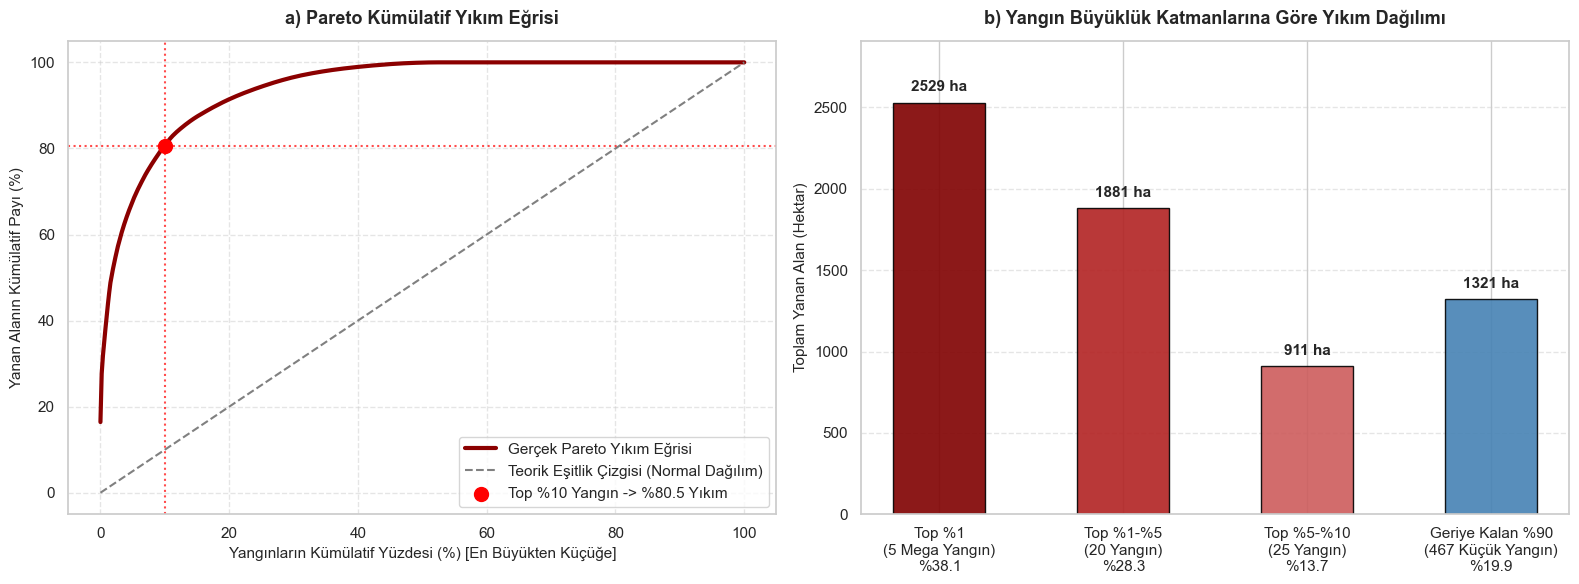

,month,day,temp,RH,wind,FFMC,DMC,DC,area
0,sep,sat,25.1,27,4.0,92.5,121.1,674.4,1090.84
1,aug,thu,27.5,27,4.9,94.8,222.4,698.6,746.28
2,jul,mon,22.6,57,4.9,89.2,103.9,431.6,278.53
3,sep,tue,18.8,40,2.2,91.0,129.5,692.6,212.88
4,sep,sat,18.2,46,1.8,92.5,121.1,674.4,200.94


In [9]:
sirali_df = df.sort_values(by='area', ascending=False).reset_index(drop=True)
toplam_yikim = sirali_df['area'].sum()
toplam_yangin = len(sirali_df)

dilimler = [0.01, 0.05, 0.10, 0.20, 1.00]
pareto_tablosu = []

for dilim in dilimler:
    adet = int(toplam_yangin * dilim) if dilim < 1.0 else toplam_yangin
    secilenler = sirali_df.head(adet)
    yaktigi_alan = secilenler['area'].sum()
    yuzde_pay = (yaktigi_alan / toplam_yikim) * 100
    pareto_tablosu.append(
        {
            'Dilim': f'Top %{int(dilim*100)}'
            if dilim < 1.0
            else '%100 (Tüm Veri)',
            'Yangın Sayısı': adet,
            'Yaktığı Toplam Alan (ha)': round(yaktigi_alan, 2),
            'Tüm Yıkımdaki Payı (%)': round(yuzde_pay, 2),
            'Ortalama Yangın Büyüklüğü (ha)': round(yaktigi_alan / adet, 2),
        }
    )

pareto_df = pd.DataFrame(pareto_tablosu)

print(
    f'Parkta 4 Yılda Yanan Toplam Alan : {toplam_yikim:.2f} hektar ({toplam_yangin} kayıt)'
)
display(pareto_df)

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
x_kum = np.linspace(0, 100, toplam_yangin)
y_kum = (sirali_df['area'].cumsum() / toplam_yikim) * 100

plt.plot(
    x_kum,
    y_kum,
    color='darkred',
    lw=3,
    label='Gerçek Pareto Yıkım Eğrisi',
)
plt.plot(
    [0, 100],
    [0, 100],
    color='gray',
    linestyle='--',
    lw=1.5,
    label='Teorik Eşitlik Çizgisi (Normal Dağılım)',
)

top10_idx = int(toplam_yangin * 0.10)
top10_val = y_kum[top10_idx]
plt.scatter(
    10,
    top10_val,
    color='red',
    s=100,
    zorder=5,
    label=f'Top %10 Yangın -> %{top10_val:.1f} Yıkım',
)
plt.axvline(x=10, color='red', linestyle=':', alpha=0.7)
plt.axhline(y=top10_val, color='red', linestyle=':', alpha=0.7)

plt.title(
    'a) Pareto Kümülatif Yıkım Eğrisi',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.xlabel('Yangınların Kümülatif Yüzdesi (%) [En Büyükten Küçüğe]', fontsize=11)
plt.ylabel('Yanan Alanın Kümülatif Payı (%)', fontsize=11)
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
top1_alan = sirali_df.head(int(toplam_yangin * 0.01))['area'].sum()
top5_alan = (
    sirali_df.iloc[
        int(toplam_yangin * 0.01) : int(toplam_yangin * 0.05)
    ]['area'].sum()
)
top10_alan = (
    sirali_df.iloc[
        int(toplam_yangin * 0.05) : int(toplam_yangin * 0.10)
    ]['area'].sum()
)
kalan90_alan = sirali_df.iloc[int(toplam_yangin * 0.10) :]['area'].sum()

katman_isimleri = [
    f'Top %1\n(5 Mega Yangın)\n%{top1_alan/toplam_yikim*100:.1f}',
    f'Top %1-%5\n(20 Yangın)\n%{top5_alan/toplam_yikim*100:.1f}',
    f'Top %5-%10\n(25 Yangın)\n%{top10_alan/toplam_yikim*100:.1f}',
    f'Geriye Kalan %90\n(467 Küçük Yangın)\n%{kalan90_alan/toplam_yikim*100:.1f}',
]
katman_alanlari = [top1_alan, top5_alan, top10_alan, kalan90_alan]
renkler = ['#800000', '#B22222', '#CD5C5C', '#4682B4']

bars = plt.bar(
    katman_isimleri,
    katman_alanlari,
    color=renkler,
    edgecolor='black',
    alpha=0.9,
    width=0.5,
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 50,
        f'{yval:.0f} ha',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
    )

plt.title(
    'b) Yangın Büyüklük Katmanlarına Göre Yıkım Dağılımı',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.ylabel('Toplam Yanan Alan (Hektar)', fontsize=11)
plt.ylim(0, max(katman_alanlari) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

display(
    sirali_df.head(5)[
        ['month', 'day', 'temp', 'RH', 'wind', 'FFMC', 'DMC', 'DC', 'area']
    ]
)